# 1. 프로젝트 소개

## 인도 중고차 가격 예측 모델

인도 중고차 온라인 플랫폼에서 수집된 매물 데이터를 분석하여, **중고차 가격(Price)에 영향을 미치는 핵심 요인을 파악하고 가격을 예측하는 머신러닝 모델**을 구축합니다.

차량의 마력·연식·주행거리 등 다양한 속성 데이터를 전처리·정제한 뒤, 파생변수를 추가로 생성하여 예측 성능을 높입니다.
선형 회귀부터 트리 기반 앙상블 모델까지 단계적으로 비교하여 최적 모델을 선정합니다.

### 데이터셋 설명

- **출처**: 인도 중고차 온라인 플랫폼 (Car.csv)
- **크기**: 7,253개 매물 × 13개 컬럼
- **타겟 변수**:  (중고차 판매 가격, 단위: 인도 루피 천 단위)

| 컬럼명 | 설명 |
|---|---|
| Name | 차량 제조사 및 모델명 |
| Location | 판매 지역 (인도 주요 도시) |
| **Price** | **중고차 가격 (타겟 변수)** |
| Year | 제조 연도 |
| Kilometers_Driven | 총 주행거리 (km) |
| Fuel_Type | 연료 유형 (Petrol / Diesel / CNG / Electric 등) |
| Transmission | 변속기 유형 (Manual / Automatic) |
| Owner_Type | 소유 이력 (First / Second / Third 등) |
| Mileage | 연비 (km/l 또는 km/kg) — 문자열 → 숫자 변환 필요 |
| Engine | 엔진 배기량 (CC) — 문자열 → 숫자 변환 필요 |
| Power | 최고 출력 마력 (bhp) — 문자열 → 숫자 변환 필요 |
| Seats | 좌석 수 |
| New_Price | 신차 가격 (결측치 86% 이상 → 분석에서 제외) |

> **주요 데이터 품질 이슈**
> - Price 결측 약 1,053건 / Mileage·Engine·Power 단위 포함 문자열 → 수치 변환 필요
> - 주행거리 650만 km, 연비 0 등 물리적으로 불가능한 극단적 이상치 존재

## 2. 라이브러리 import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import warnings


warnings.filterwarnings('ignore')

%matplotlib inline

matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rc('axes', unicode_minus=False)

sns.set(font='Malgun Gothic', rc={'axes.unicode_minus': False}, style='whitegrid')

## 3. 데이터 로드

In [2]:
df = pd.read_csv(r"D:\BigData_수업용\yay-20260525T102121Z-3-001\yay\2. Big Data 분석 실습파일\Car.csv", encoding = 'euc-kr')
df.head()


,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,CNG,Manual,First,26.6 kmpl,998 CC,58.16 bhp,5.0,NaN
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN
2,Honda Jazz V,Chennai,6898.32,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh
3,Maruti Ertiga VDI,Chennai,9197.76,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,27194.71,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN


## 4. 데이터 구조 확인 (EDA) : 데이터 기본 검색

In [3]:
print("=== 데이터 정보 및 결측치 확인 ===")
df.info()
print("\n=== 기술 통계량 확인 ===")
display(df.describe())
print("\n=== 결측치 빈도 집계 ===")
print(df.isnull().sum())

=== 데이터 정보 및 결측치 확인 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               7253 non-null   object 
 1   Location           7253 non-null   object 
 2   Price              6200 non-null   float64
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
dtypes: float64(2), int64(2), object(9)
memory usage: 736.8+ KB

=== 기술 통계량 확인 ===


,Price,Year,Kilometers_Driven,Seats
count,6200.000000,7253.000000,7.253000e+03,7200.000000
mean,14912.514750,2013.365366,5.869906e+04,5.279722
std,17674.318464,3.254421,8.442772e+04,0.811660
min,7.080000,1996.000000,1.710000e+02,0.000000
25%,5365.360000,2011.000000,3.400000e+04,5.000000
50%,8814.520000,2014.000000,5.341600e+04,5.000000
75%,15869.972500,2016.000000,7.300000e+04,5.000000
max,245273.600000,2019.000000,6.500000e+06,10.000000



=== 결측치 빈도 집계 ===
Name                    0
Location                0
Price                1053
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
dtype: int64


### "데이터 정제(Cleaning)가 시급한 상태: 타겟 변수의 결측치 해결과 문자열 데이터의 숫자화가 최우선 과제입니다."

- 타겟 변수(Price) 불안정: 예측해야 할 Price에 약 1,000건의 결측치가 있어 학습 전 삭제가 필요합니다.

- 자료형 불일치: Mileage, Engine, Power가 숫자형이 아닌 object(문자열)로 되어 있어 계산이 불가능하므로 단위 분리가 필수입니다.

- 불필요한 컬럼: New_Price는 데이터의 86% 이상이 비어있어(7,253개 중 1,006개만 존재) 분석 가치가 낮으므로 삭제하는 것이 합리적입니다.

- 잠재적 이상치: 주행거리(Kilometers_Driven)와 가격(Price)의 최댓값 차이가 클 것으로 예상되어 시각화를 통한 확인이 필요합니다.

## 5. 데이터 정제 (단위 분리 및 자료형 변환)

In [4]:
# 단위 변환
df.drop('New_Price', axis=1, inplace=True)

# Mileage 처리
df[['Mileage_Val', 'Mileage_Unit']] = df['Mileage'].str.split(expand=True)
df['Mileage'] = df['Mileage_Val'].astype(float)

# Engine 처리
df[['Engine_Val', 'Engine_Unit']] = df['Engine'].str.split(expand=True)
df['Engine'] = df['Engine_Val'].astype(float)

# Power 처리
df[['Power_Val', 'Power_Unit']] = df['Power'].str.split(expand=True)
df['Power'] = pd.to_numeric(df['Power_Val'], errors='coerce')

df.drop(['Mileage_Val', 'Mileage_Unit', 'Engine_Val', 'Engine_Unit', 'Power_Val', 'Power_Unit'], axis=1, inplace=True)

print(df[['Mileage', 'Engine', 'Power']].head())
print(df[['Mileage', 'Engine', 'Power']].info())

   Mileage  Engine   Power
0    26.60   998.0   58.16
1    19.67  1582.0  126.20
2    18.20  1199.0   88.70
3    20.77  1248.0   88.76
4    15.20  1968.0  140.80
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Mileage  7251 non-null   float64
 1   Engine   7207 non-null   float64
 2   Power    7078 non-null   float64
dtypes: float64(3)
memory usage: 170.1 KB
None


|변환 전|변환 후|
|------|---|
|"88.5 bhp" (문자열)|88.5 (숫자형 float)|
|"187.74 bhp" (문자열)|187.74 (숫자형 float)|
|"null bhp" (문자열)|NaN (판다스 공식 결측치)|

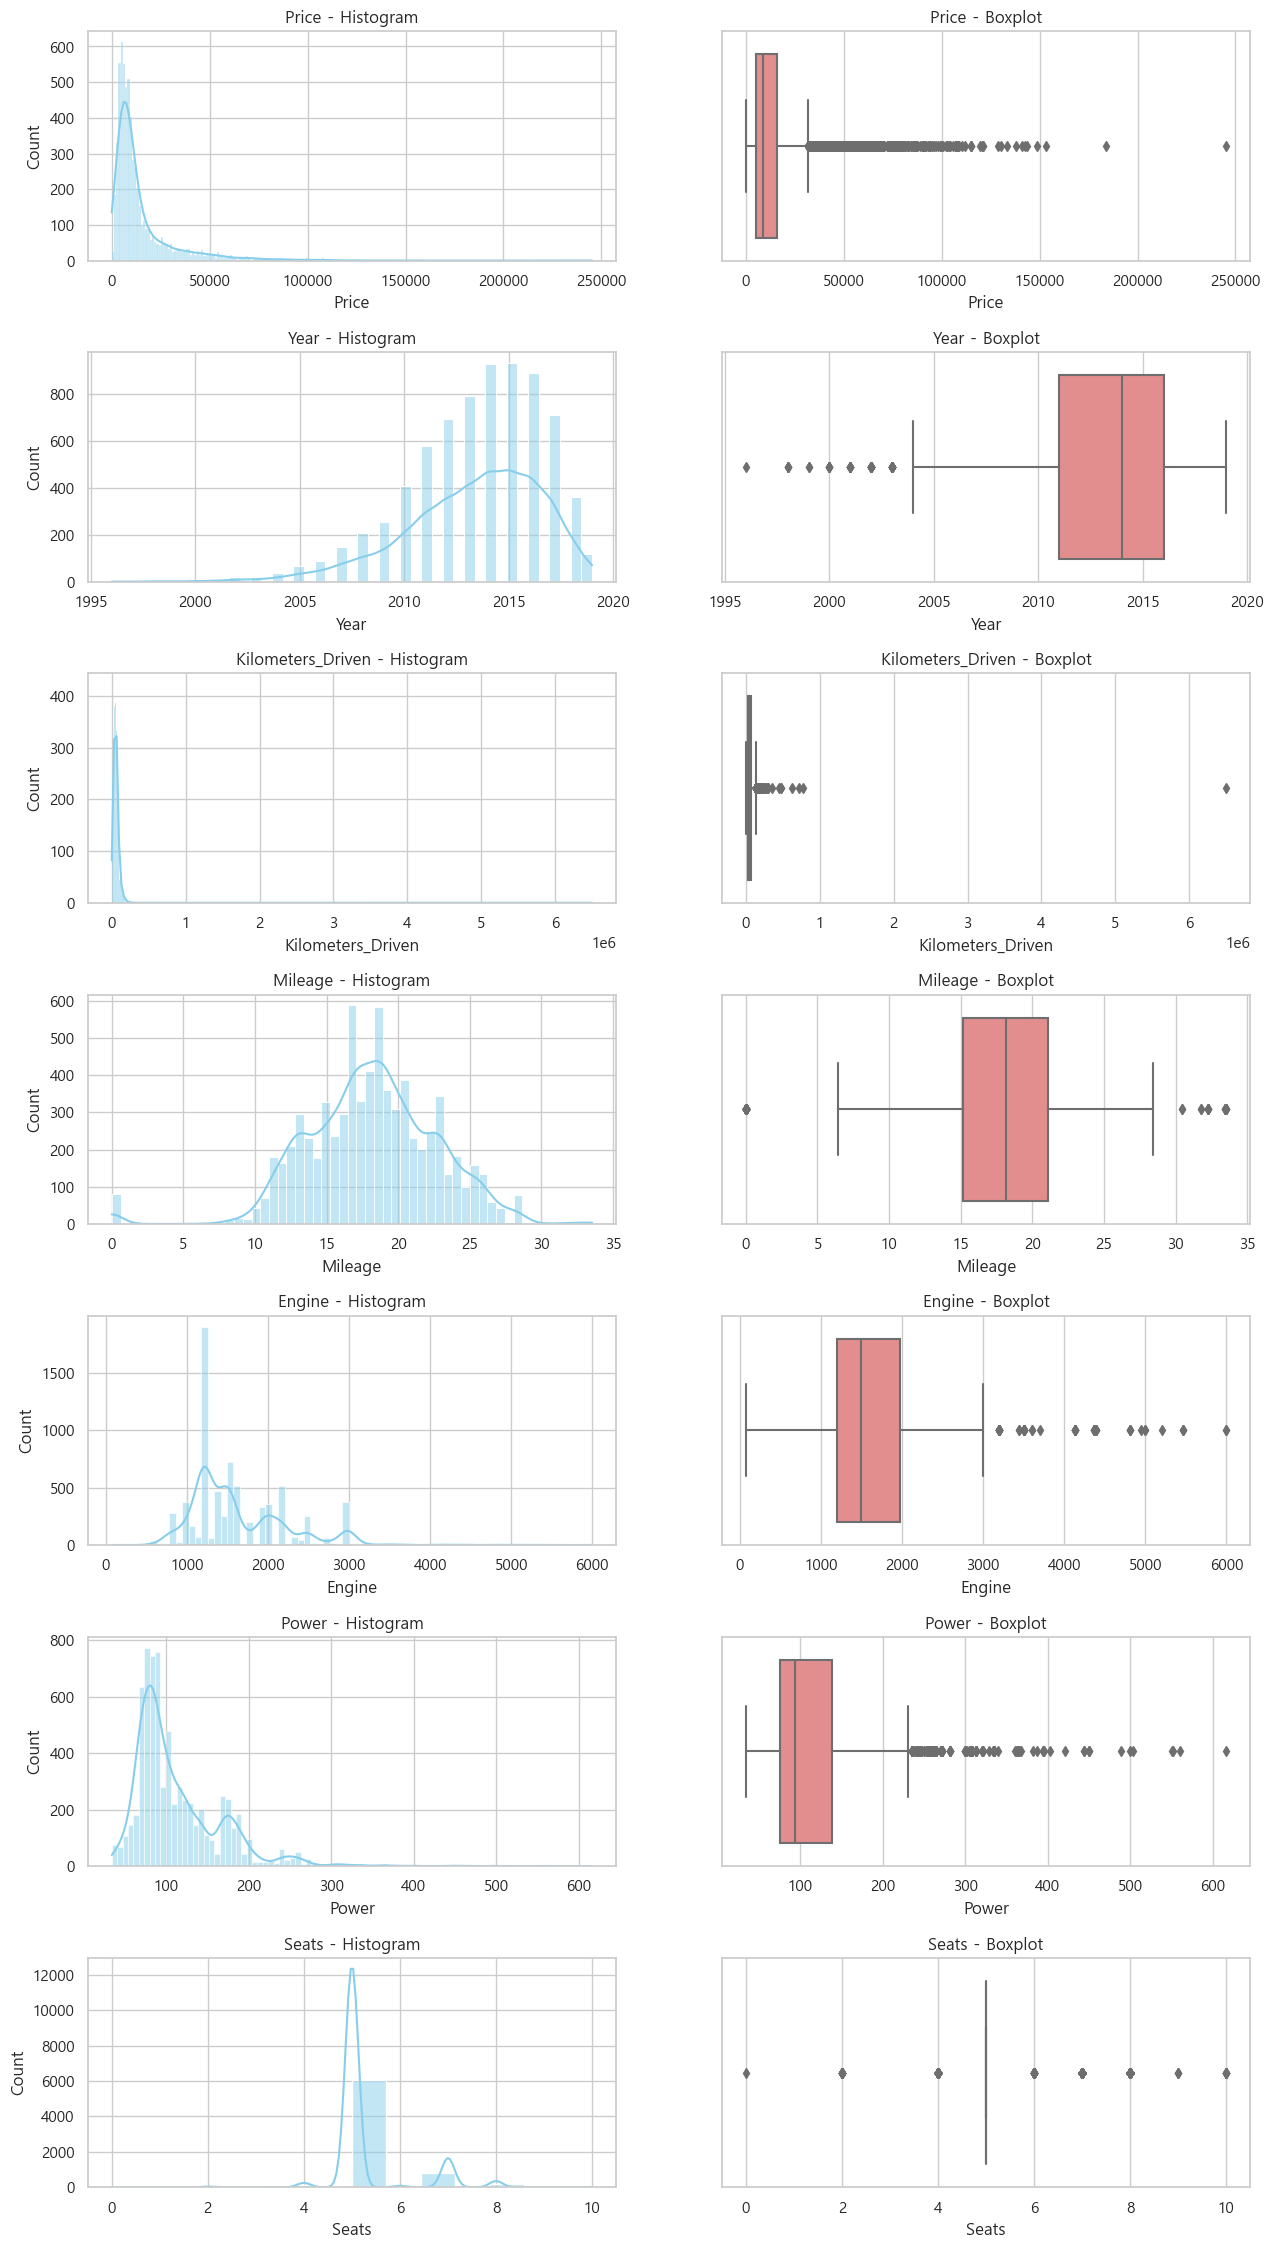

In [5]:
numeric_cols = ['Price', 'Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats']

fig, axes = plt.subplots(nrows=len(numeric_cols), ncols=2, figsize=(15, 4 * len(numeric_cols)))
fig.subplots_adjust(hspace=0.4)

for i, col in enumerate(numeric_cols):
    # 1. Histogram (분포 확인)
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Histogram', fontsize=12)
    
    # 2. Boxplot (이상치 확인)
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'{col} - Boxplot', fontsize=12)

plt.show()

#### 데이터의 3가지 핵심 문제점  
- 극단적 이상치로 인한 데이터 왜곡: 주행거리 650만km, 가격 25만 등 말도 안 되는 오타 수준의 수치들이 포함되어 전체 그래프가 한쪽으로 심하게 찌그러져 있습니다.

- 비논리적 데이터 오류 발생: 연비(Mileage)가 0이거나 좌석수(Seats)가 0인 차들처럼 실제 존재할 수 없는 물리적 오류 데이터가 섞여 있어 분석의 신뢰도를 떨어뜨립니다.

- 분석 불가능한 스케일: 소수의 슈퍼카나 노후 차량이 데이터의 범위를 비정상적으로 넓혀 놓아, 우리가 실제로 예측해야 할 일반 차량들의 특징이 그래프상에서 모두 뭉쳐버려 구분이 불가능합니다.

### 이상치 확인 (직접 확인이 필요한 데이터)

In [6]:
print("\n=== 이상치 의심 데이터 확인 ===")
display(df[df['Kilometers_Driven'] > 1000000]) # 과도한 주행거리
display(df[df['Price'] > 200000])              # 과도한 가격
display(df[df['Seats'] < 1])                    # 좌석수 0개
display(df[df['Mileage'] < 3])                  # 비정상 연비


=== 이상치 의심 데이터 확인 ===


,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
2328,BMW X5 xDrive 30d M Sport,Chennai,99642.4,2017,6500000,Diesel,Automatic,First,15.97,2993.0,258.0,5.0


,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,Hyderabad,245273.6,2017,25000,Diesel,Automatic,First,13.33,2993.0,255.0,5.0


,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
3999,Audi A4 3.2 FSI Tiptronic Quattro,Hyderabad,27593.28,2012,125000,Petrol,Automatic,First,10.5,3197.0,NaN,0.0


,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
14,Land Rover Freelander 2 TD4 SE,Pune,26826.80,2012,85000,Diesel,Automatic,Second,0.0,2179.0,115.0,5.0
67,Mercedes-Benz C-Class Progressive C 220d,Coimbatore,54680.68,2019,15369,Diesel,Automatic,First,0.0,1950.0,194.0,5.0
79,Hyundai Santro Xing XL,Hyderabad,1992.85,2005,87591,Petrol,Manual,First,0.0,1086.0,NaN,5.0
194,Honda City 1.5 GXI,Ahmedabad,4522.23,2007,60006,Petrol,Manual,First,0.0,NaN,NaN,NaN
229,Ford Figo Diesel,Bangalore,5518.66,2015,70436,Diesel,Manual,First,0.0,1498.0,99.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
6633,Mahindra TUV 300 P4,Kolkata,NaN,2016,27000,Diesel,Manual,First,0.0,NaN,NaN,NaN
6697,Hyundai Santro Xing XL,Jaipur,NaN,2007,85000,Petrol,Manual,Second,0.0,1086.0,NaN,5.0
6857,Land Rover Freelander 2 TD4 SE,Mumbai,NaN,2011,87000,Diesel,Automatic,First,0.0,2179.0,115.0,5.0
6957,Honda Jazz 2020 Petrol,Kochi,NaN,2019,11574,Petrol,Manual,First,0.0,1199.0,88.7,NaN


## 6. 결측치 및 이상치 상세 처리

In [7]:
# [1] 이상치 처리: 주행거리 100만km 이상 데이터 삭제 
df = df[df['Kilometers_Driven'] < 1000000]

# [2] Price(타겟 변수) 결측치 행 삭제
df.dropna(subset=['Price'], inplace=True)

# [3] Mileage 처리 (연비 0 보정 및 전기차 결측치 채우기)
# 연비가 0인 데이터를 NaN으로 처리하여 결측치와 함께 보정합니다.
df.loc[df['Mileage'] <= 0, 'Mileage'] = np.nan

# 전기차(Electric) Mileage 평균 계산 및 대입
elec_mean = df[df['Fuel_Type'] == 'Electric']['Mileage'].mean()
if pd.isna(elec_mean) or elec_mean == 0:
    elec_mean = 0.0 
df.loc[(df['Fuel_Type'] == 'Electric') & (df['Mileage'].isnull()), 'Mileage'] = elec_mean

# 나머지 연비 결측치는 전체 중앙값으로 채우기
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)

# [4] Seats(좌석 수) 처리
# 0인 값을 NaN으로 바꾼 후 최빈값(Mode) 대입
df.loc[df['Seats'] == 0, 'Seats'] = np.nan
df['Seats'].fillna(df['Seats'].mode()[0], inplace=True)

# [5] Engine & Power (중앙값 대입)
df['Engine'].fillna(df['Engine'].median(), inplace=True)
df['Power'].fillna(df['Power'].median(), inplace=True)

# [6] 최종 결과 확인
print("=== 최종 결측치 처리 결과 ===")
print(df.isnull().sum())
print("\n=== 데이터 정제 완료 ===")
display(df.head(3))

=== 최종 결측치 처리 결과 ===
Name                 0
Location             0
Price                0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
dtype: int64

=== 데이터 정제 완료 ===


,Name,Location,Price,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats
0,Maruti Wagon R LXI CNG,Mumbai,2682.68,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0
1,Hyundai Creta 1.6 CRDi SX Option,Pune,19162.00,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0
2,Honda Jazz V,Chennai,6898.32,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0


#### 각 변수별 고유값 개수/목록 확인

In [8]:
# 각 변수별 고유값 개수와 목록 확인
for col in ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']:
    print(f"[{col}] ({df[col].nunique()}개)")
    print(df[col].unique())
    print("-" * 30)

[Location] (11개)
['Mumbai' 'Pune' 'Chennai' 'Coimbatore' 'Hyderabad' 'Jaipur' 'Kochi'
 'Kolkata' 'Delhi' 'Bangalore' 'Ahmedabad']
------------------------------
[Fuel_Type] (5개)
['CNG' 'Diesel' 'Petrol' 'LPG' 'Electric']
------------------------------
[Transmission] (2개)
['Manual' 'Automatic']
------------------------------
[Owner_Type] (4개)
['First' 'Second' 'Fourth & Above' 'Third']
------------------------------


###### Name은 무수히 다양한 값이 있습니다.

## 7. 파생변수 생성

In [9]:
# [1] 전처리용 복사본 생성 (원본 보존)
df_processed = df.copy()

# [2] 브랜드 및 모델명 분리
df_processed[['Brand', 'Model_Name']] = df_processed['Name'].str.split(' ', n=1, expand=True)

# [3] 그룹화 함수 정의
def group_brand(brand):
    luxury = ['Audi', 'Land', 'Mercedes-Benz', 'BMW', 'Porsche', 'Jaguar', 'Volvo', 'Mini', 'Bentley', 'Lamborghini']
    mainstream = ['Hyundai', 'Honda', 'Toyota', 'Volkswagen', 'Nissan', 'Renault', 'Ford', 'Skoda', 'Jeep', 'Mitsubishi', 'ISUZU']
    if brand in luxury: return 'Luxury'
    if brand in mainstream: return 'Mainstream'
    return 'Economy'

def group_city(city):
    x_grade = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Ahmedabad']
    return 1 if city in x_grade else 0

def group_fuel(fuel):
    return fuel if fuel in ['Diesel', 'Petrol'] else 'Others'

# [4] 변수 변환 및 매핑 적용
df_processed['Brand_Group'] = df_processed['Brand'].apply(group_brand)
df_processed['City_Tier'] = df_processed['Location'].apply(group_city)
df_processed['Fuel_Group'] = df_processed['Fuel_Type'].apply(group_fuel)
df_processed['Transmission_Numeric'] = df_processed['Transmission'].map({'Automatic': 1, 'Manual': 0})
df_processed['Owner_Score'] = df_processed['Owner_Type'].map({'First': 1, 'Second': 2, 'Third': 3, 'Fourth & Above': 4})    # 순서형 매핑(Ordinal Mapping)

# [5] 차량 나이 계산 (현재 시점 반영)
df_processed['Vehicle_Age'] = 2026 - df_processed['Year']

# [6] 최종 분석용 데이터프레임 구축 (One-Hot Encoding)
# 분석에 사용된 원본 범주형 컬럼들 제거
drop_cols = ['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Model_Name', 'Year']
df_final = df_processed.drop(columns=drop_cols)

# 원-핫 인코딩 수행 (Brand_Group, Fuel_Group)
df_final = pd.get_dummies(df_final, columns=['Brand_Group', 'Fuel_Group'], drop_first=True)

# [7] 결과 확인
print("--- 전처리 완료 후 컬럼 정보 ---")
df_final.info()
print("\n--- 최종 데이터 샘플 ---")
display(df_final.head())

--- 전처리 완료 후 컬럼 정보 ---
<class 'pandas.core.frame.DataFrame'>
Int64Index: 6199 entries, 0 to 7236
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   6199 non-null   float64
 1   Kilometers_Driven       6199 non-null   int64  
 2   Mileage                 6199 non-null   float64
 3   Engine                  6199 non-null   float64
 4   Power                   6199 non-null   float64
 5   Seats                   6199 non-null   float64
 6   City_Tier               6199 non-null   int64  
 7   Transmission_Numeric    6199 non-null   int64  
 8   Owner_Score             6199 non-null   int64  
 9   Vehicle_Age             6199 non-null   int64  
 10  Brand_Group_Luxury      6199 non-null   uint8  
 11  Brand_Group_Mainstream  6199 non-null   uint8  
 12  Fuel_Group_Others       6199 non-null   uint8  
 13  Fuel_Group_Petrol       6199 non-null   uint8  
dtypes: float64(5), in

,Price,Kilometers_Driven,Mileage,Engine,Power,Seats,City_Tier,Transmission_Numeric,Owner_Score,Vehicle_Age,Brand_Group_Luxury,Brand_Group_Mainstream,Fuel_Group_Others,Fuel_Group_Petrol
0,2682.68,72000,26.60,998.0,58.16,5.0,1,0,1,16,0,0,1,0
1,19162.00,41000,19.67,1582.0,126.20,5.0,1,0,1,11,0,1,0,0
2,6898.32,46000,18.20,1199.0,88.70,5.0,1,0,1,15,0,1,0,1
3,9197.76,87000,20.77,1248.0,88.76,7.0,1,0,1,14,0,0,0,0
4,27194.71,40670,15.20,1968.0,140.80,5.0,0,1,2,13,1,0,0,0


#### 이상치 직접 목격

In [10]:
# [1] 주행거리 100만km 이상 차량 확인
print("=== 주행거리 1,000,000km 이상 데이터 ===")
# df를 df_processed로 변경
display(df_processed[df_processed['Kilometers_Driven'] >= 1000000][['Name', 'Year', 'Kilometers_Driven', 'Price']])

# [2] 가격 20만 이상 초고가 차량 확인
print("\n=== 가격 200,000 이상 데이터 ===")
# df를 df_processed로 변경
display(df_processed[df_processed['Price'] >= 200000][['Name', 'Brand_Group', 'Price', 'Power']])

# [3] 추가 점검: 연비(Mileage)가 0인 데이터
print("\n=== 연비가 0인 데이터 (점검 필요) ===")
display(df_processed[df_processed['Mileage'] == 0][['Name', 'Fuel_Type', 'Mileage']].head())

# 1. 엔진 괴물들 확인 (5000cc 이상)
print("--- [엔진 확인] 5000cc 이상 차량 ---")
display(df_processed[df_processed['Engine'] >= 5000][['Name', 'Engine', 'Price']])

# 2. 노익장 차량 확인 (25년 이상)
print("\n--- [연식 확인] 25년 이상 된 차량 ---")
# df_processed를 사용해야 Vehicle_Age를 찾을 수 있습니다.
display(df_processed[df_processed['Vehicle_Age'] >= 25][['Name', 'Year', 'Vehicle_Age', 'Price']])

=== 주행거리 1,000,000km 이상 데이터 ===


,Name,Year,Kilometers_Driven,Price



=== 가격 200,000 이상 데이터 ===


,Name,Brand_Group,Price,Power
4079,Land Rover Range Rover 3.0 Diesel LWB Vogue,Luxury,245273.6,255.0



=== 연비가 0인 데이터 (점검 필요) ===


,Name,Fuel_Type,Mileage
4446,Mahindra E Verito D4,Electric,0.0
4904,Toyota Prius 2009-2016 Z4,Electric,0.0


--- [엔진 확인] 5000cc 이상 차량 ---


,Name,Engine,Price
152,Mercedes-Benz S Class 2005 2013 S 500,5461.0,45988.80
4691,Mercedes-Benz SLK-Class 55 AMG,5461.0,137966.40
4722,Mercedes-Benz SL-Class SL 500,5461.0,45222.32
5088,Jaguar XJ 5.0 L V8 Supercharged,5000.0,77659.75
5521,Bentley Continental Flying Spur,5998.0,90444.64
5781,Lamborghini Gallardo Coupe,5204.0,183955.20
5919,Jaguar F Type 5.0 V8 S,5000.0,153296.00
6354,Bentley Flying Spur W12,5998.0,5748.60



--- [연식 확인] 25년 이상 된 차량 ---


,Name,Year,Vehicle_Age,Price
315,Tata Sumo Delux,2000,26,2299.44
613,Mahindra Bolero ZLX BSIII,2000,26,2989.27
1224,Maruti Zen VX,1999,27,1180.38
1845,Honda City 1.3 EXI,1999,27,1379.66
1999,Mercedes-Benz E-Class 220 CDI,2001,25,7664.80
2737,Maruti Wagon R Vx,2001,25,1073.07
3138,Maruti Zen LXI,1998,28,689.83
3749,Mercedes-Benz E-Class 250 D W 210,1998,28,5978.54
3806,Honda City 1.5 EXI,2001,25,2222.79
3963,Mitsubishi Lancer 1.5 SFXi,2001,25,1532.96


#### 결과 분석 및 정제 전략 수립
- 주행거리 1,000,000km 이상 데이터:  BMW X5 xDrive 30d M Sport 가..? 말이 안된다. 오류값일 가능성이 높음
- 가격 200,000 이상 데이터: 실제로 비싼 차임 (Land Rover Range Rover 3.0 Diesel LWB Vogue	)
- [엔진 확인] 5000cc 이상 차량 : 5000cc 이상 차량 존재 자체는 정상(대부분 스포츠카) 다만 분포 왜곡, 이상치 영향, 가격 스케일 급상승 이유로 상위 99% 기준으로 자르도록 하겠습ㄴ디ㅏㅣ.
- 디젤/가솔린 차량인데 연비 0 : 결측치 대체 실패, 잘못 입력된 데이터, 정보 누락
- 25년 이상된 차량 : 전부 실제 1990년대~2000년대 초반 차량입니다.

#### 상관계수 확인

In [11]:
# 숫자형 데이터들만 모아서 가격(Price)과의 상관계수 계산
correlations = df_final.corr()['Price'].sort_values(ascending=False)

print("=== 중고차 가격에 영향을 주는 핵심 인자 (상관계수 순) ===")
print(correlations)

=== 중고차 가격에 영향을 주는 핵심 인자 (상관계수 순) ===
Price                     1.000000
Power                     0.751990
Brand_Group_Luxury        0.708759
Engine                    0.638843
Transmission_Numeric      0.581521
Seats                     0.054525
Fuel_Group_Others        -0.055901
Owner_Score              -0.100538
City_Tier                -0.101493
Kilometers_Driven        -0.167226
Brand_Group_Mainstream   -0.267956
Vehicle_Age              -0.302888
Fuel_Group_Petrol        -0.304406
Mileage                  -0.322561
Name: Price, dtype: float64


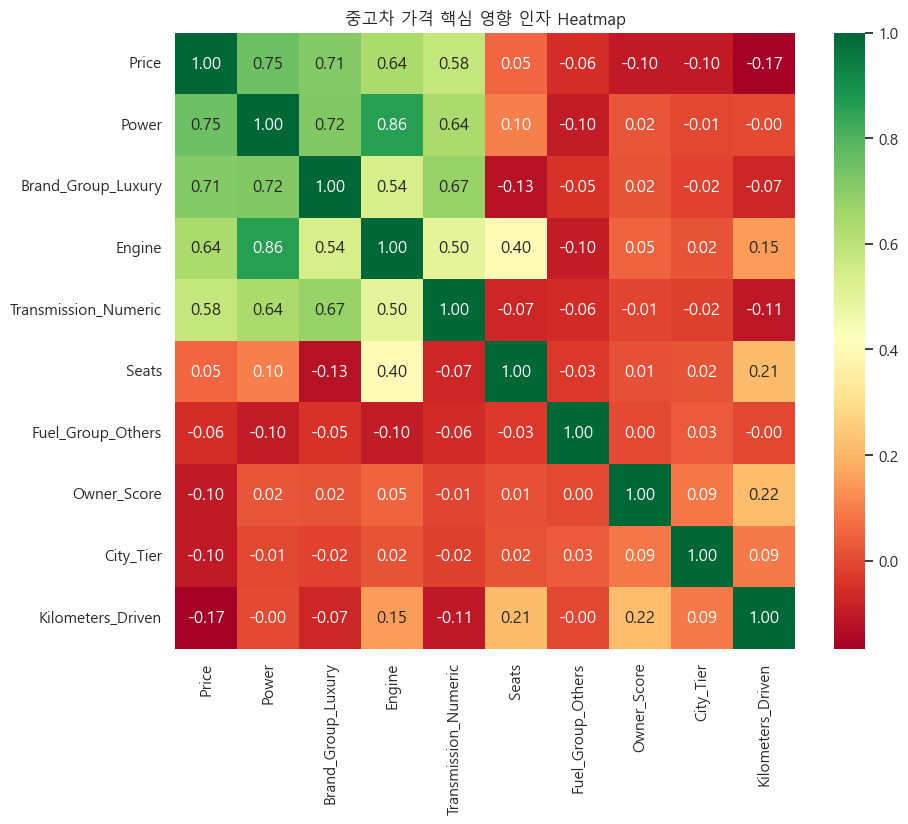

In [12]:
# 상관관계 상위 10개 항목만 추출
top_features = correlations.index[:10]
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[top_features].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("중고차 가격 핵심 영향 인자 Heatmap")
plt.show()

#### 핵심 변수 선택

In [13]:
# [1] 새로운 데이터프레임 생성 (이상치 제거를 위해)
features = [
    'Price', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 
    'Vehicle_Age', 'Owner_Score', 'City_Tier', 'Transmission_Numeric'
]

# Brand_Group과 Fuel_Group의 원-핫 인코딩 컬럼들을 찾아 합칩니다.
final_cols = features + [col for col in df_final.columns if 'Brand_Group' in col or 'Fuel_Group' in col]

df_model = df_final[final_cols].copy()

print("--- 모델 학습용 최종 변수 구성 ---")
print(df_model.columns)
print(f"\n최종 변수 개수: {len(df_model.columns)}개")

--- 모델 학습용 최종 변수 구성 ---
Index(['Price', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
       'Vehicle_Age', 'Owner_Score', 'City_Tier', 'Transmission_Numeric',
       'Brand_Group_Luxury', 'Brand_Group_Mainstream', 'Fuel_Group_Others',
       'Fuel_Group_Petrol'],
      dtype='object')

최종 변수 개수: 14개


## 9. 근거 있는 이상치 제거

In [14]:
# 1. 정제 전 개수 (이상치 처리 전 df_model의 행 수)
original_count = len(df_model) # 또는 정제 시작 전 시점의 개수


# [1] 주행거리 오류값 제거 (100만km 이상 BMW 등).
# 100만km 이상은 데이터 자체를 신뢰할 수 없으므로 행 삭제, 이런 데이터를 중앙값으로 채우기엔 모델에 주는 악영향이 너무 크기에 과감히 삭제
df_model = df_model[df_model['Kilometers_Driven'] < 1000000]

# [2] 엔진 5000cc 이상 상위 1% 컷오프
engine_99 = df_model['Engine'].quantile(0.99)
df_model = df_model[df_model['Engine'] <= engine_99]

# [3] 연비 0인 데이터 처리 (보정 전략)
df_model.loc[df_model['Mileage'] <= 0, 'Mileage'] = np.nan
df_model['Mileage'].fillna(df_model['Mileage'].median(), inplace=True)

# [4] 25년 이상 된 차량 제거 
df_model = df_model[df_model['Vehicle_Age'] < 25]

# [5] 가격 상위 0.5% 컷오프 
price_995 = df_model['Price'].quantile(0.995)
df_model = df_model[df_model['Price'] <= price_995]

# 2. 정제 후 개수
final_count = len(df_model)

# 3. 통계 계산
deleted_count = original_count - final_count
deleted_rate = (deleted_count / original_count) * 100

print(f"=== 데이터 정제 최종 리포트 ===")
print(f"1. 정제 전 데이터 개수: {original_count:,}개")
print(f"2. 정제 후 데이터 개수: {final_count:,}개")
print(f"3. 삭제된 데이터 개수: {deleted_count:,}개")
print(f"4. 데이터 삭제 비율: {deleted_rate:.2f}%")
print("-" * 30)
print(f"분석 결과: 약 {deleted_rate:.2f}%의 이상치를 제거하여 모델의 안정성을 확보했습니다.")

=== 데이터 정제 최종 리포트 ===
1. 정제 전 데이터 개수: 6,199개
2. 정제 후 데이터 개수: 6,088개
3. 삭제된 데이터 개수: 111개
4. 데이터 삭제 비율: 1.79%
------------------------------
분석 결과: 약 1.79%의 이상치를 제거하여 모델의 안정성을 확보했습니다.


### 체크

In [15]:
print("=== 데이터 정보 및 결측치 확인 ===")
df_model.info()
print("\n=== 기술 통계량 확인 ===")
display(df_model.describe())
print("\n=== 결측치 빈도 집계 ===")
print(df_model.isnull().sum())

=== 데이터 정보 및 결측치 확인 ===
<class 'pandas.core.frame.DataFrame'>
Int64Index: 6088 entries, 0 to 7236
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price                   6088 non-null   float64
 1   Kilometers_Driven       6088 non-null   int64  
 2   Mileage                 6088 non-null   float64
 3   Engine                  6088 non-null   float64
 4   Power                   6088 non-null   float64
 5   Seats                   6088 non-null   float64
 6   Vehicle_Age             6088 non-null   int64  
 7   Owner_Score             6088 non-null   int64  
 8   City_Tier               6088 non-null   int64  
 9   Transmission_Numeric    6088 non-null   int64  
 10  Brand_Group_Luxury      6088 non-null   uint8  
 11  Brand_Group_Mainstream  6088 non-null   uint8  
 12  Fuel_Group_Others       6088 non-null   uint8  
 13  Fuel_Group_Petrol       6088 non-null   uint8  
dtypes: float64(5), i

,Price,Kilometers_Driven,Mileage,Engine,Power,Seats,Vehicle_Age,Owner_Score,City_Tier,Transmission_Numeric,Brand_Group_Luxury,Brand_Group_Mainstream,Fuel_Group_Others,Fuel_Group_Petrol
count,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000,6088.000000
mean,13971.994749,57155.719777,18.489028,1589.570795,110.236388,5.276774,12.534001,1.197273,0.716491,0.277760,0.153745,0.534987,0.011334,0.456307
std,14958.061123,37638.720250,4.096969,542.247325,47.414347,0.786221,3.184924,0.448071,0.450738,0.447931,0.360734,0.498815,0.105864,0.498128
min,7.080000,171.000000,8.200000,72.000000,34.200000,2.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5365.360000,33012.000000,15.630000,1197.000000,75.940000,5.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8714.875000,52621.500000,18.480000,1462.000000,97.600000,5.000000,12.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,15176.300000,72216.250000,21.105000,1968.000000,136.000000,5.000000,14.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,99642.400000,775000.000000,33.540000,2999.000000,444.000000,10.000000,24.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



=== 결측치 빈도 집계 ===
Price                     0
Kilometers_Driven         0
Mileage                   0
Engine                    0
Power                     0
Seats                     0
Vehicle_Age               0
Owner_Score               0
City_Tier                 0
Transmission_Numeric      0
Brand_Group_Luxury        0
Brand_Group_Mainstream    0
Fuel_Group_Others         0
Fuel_Group_Petrol         0
dtype: int64


### 10. 최종 시각화 분석 결과

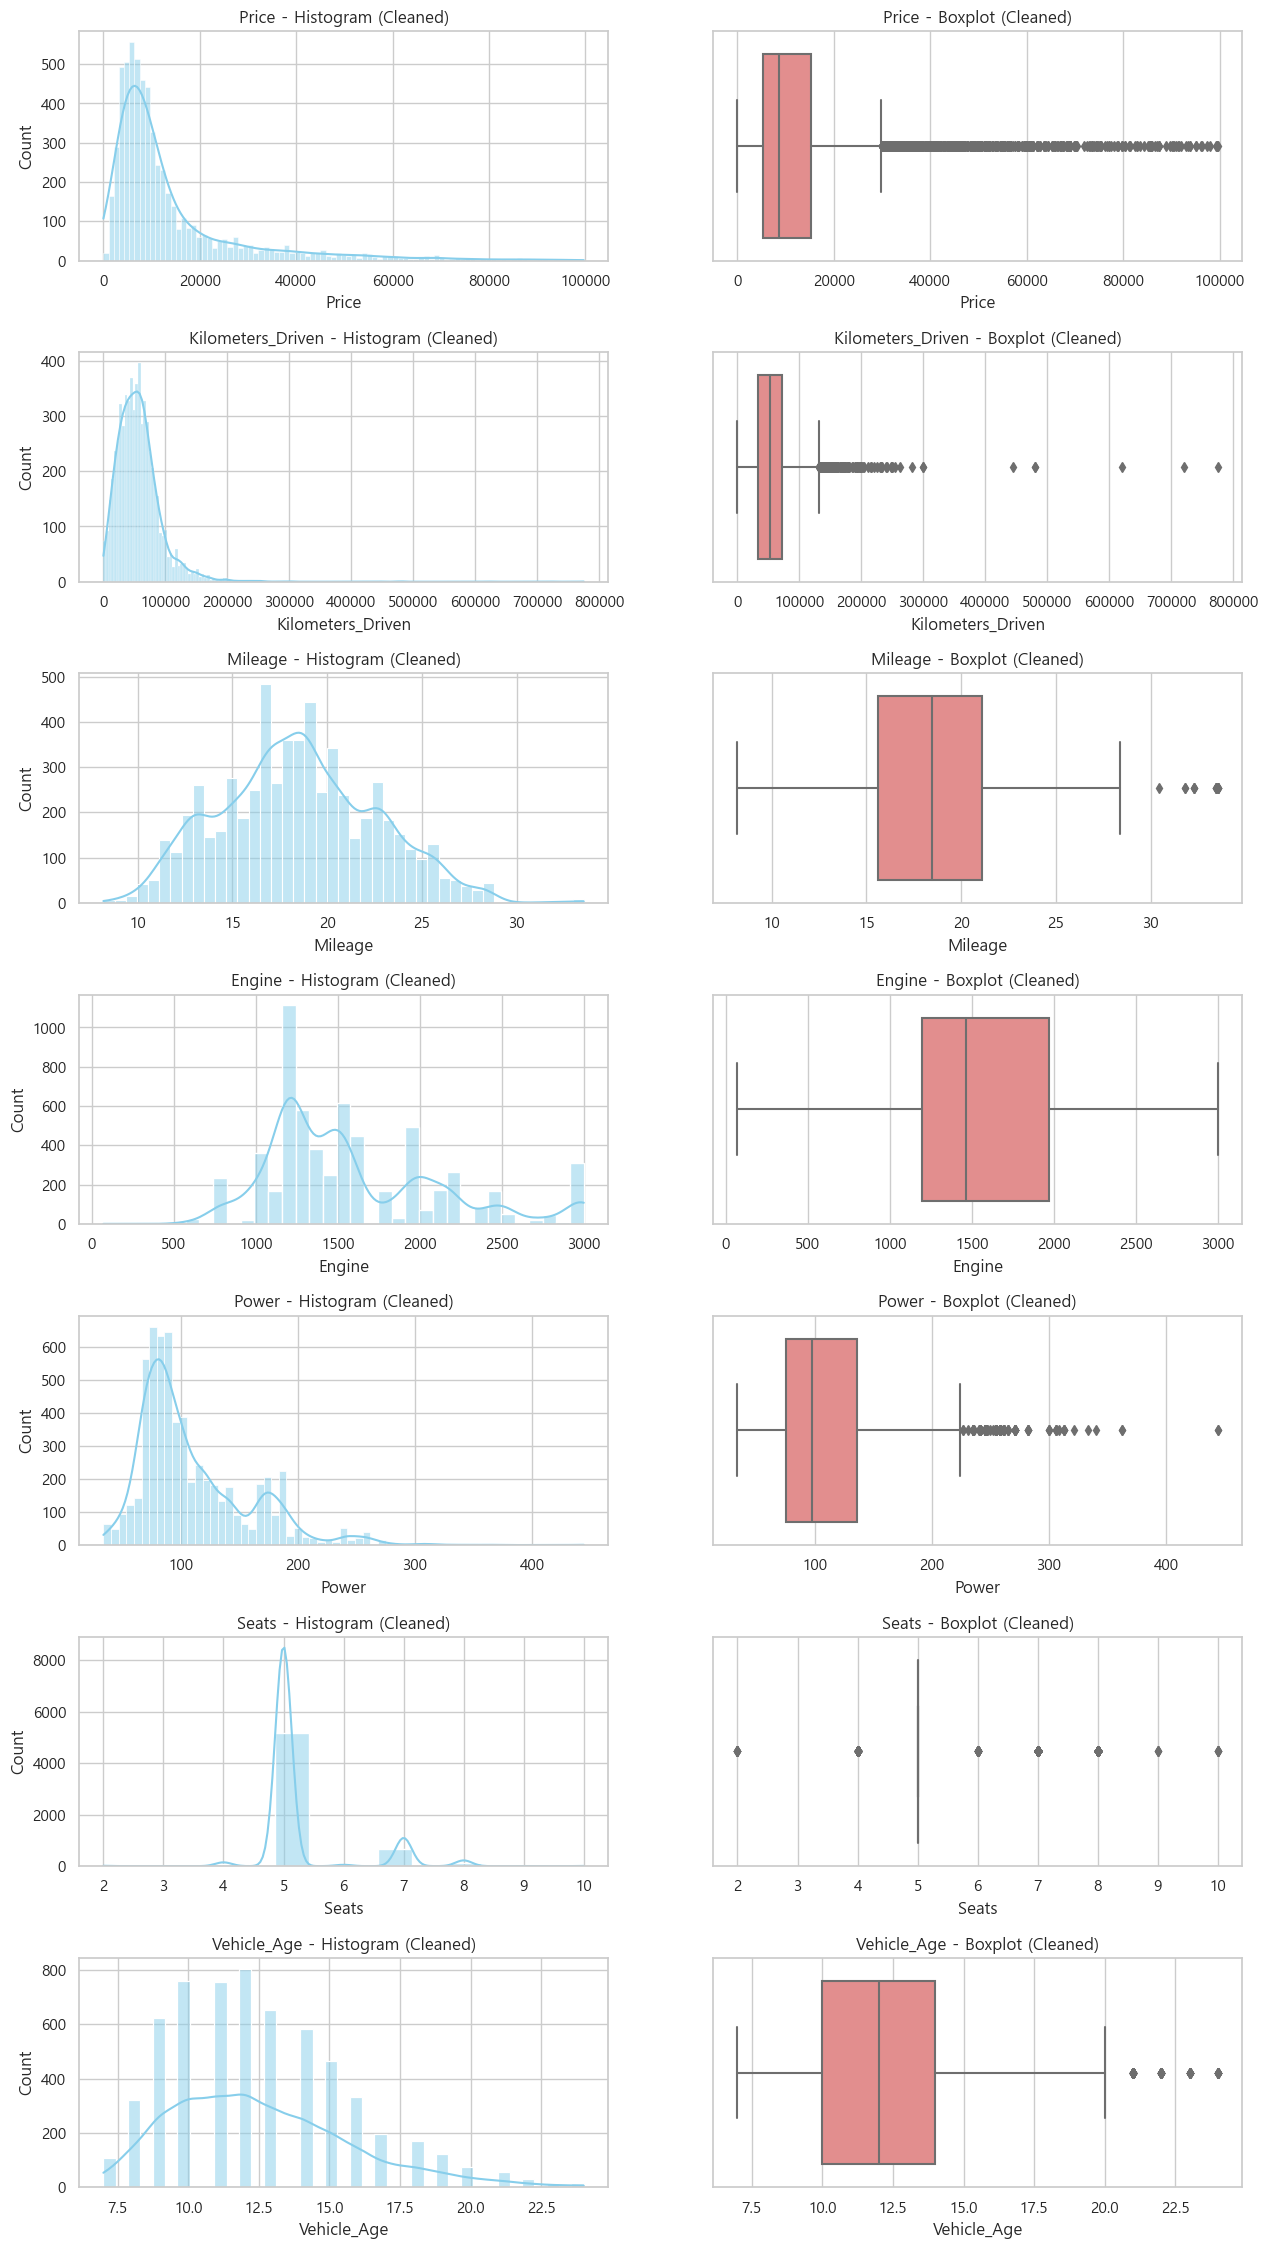

In [16]:
# df_model에 남아있는 수치형 컬럼들만 선택 (Year 대신 Vehicle_Age를 사용)
final_numeric_cols = ['Price', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Vehicle_Age']

# 그래프 크기 및 레이아웃 설정
fig, axes = plt.subplots(nrows=len(final_numeric_cols), ncols=2, figsize=(15, 4 * len(final_numeric_cols)))
fig.subplots_adjust(hspace=0.4)

for i, col in enumerate(final_numeric_cols):
    # 1. Histogram (정제 후 분포 확인)
    sns.histplot(df_model[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Histogram (Cleaned)', fontsize=12)
    
    # 2. Boxplot (이상치 제거 확인)
    sns.boxplot(x=df_model[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'{col} - Boxplot (Cleaned)', fontsize=12)

plt.show()

|항목|전처리 전 (Original)|전처리 후 (Cleaned)|개선 효과|
|------|---|---|---|
|분포의 가독성|특정 오타(주행거리 650만km)로 인해 그래프가 왼쪽으로 치우치고 찌그러짐|데이터가 유효한 범위 내에서 골고루 분포되어 시각적 가독성 확보|데이터 해석력 증대|
|이상치(Outlier)|Boxplot 상에서 박스와 동떨어진 극단적 점(•)들이 다수 존재|극단치가 제거되어 데이터의 중심 경향성(평균, 중앙값)이 안정화됨|모델 예측 정확도 향상|
|데이터 정규성|연비 0, 마력 600 등 편향된 데이터로 인해 분석 왜곡 가능성 높음|히스토그램이 부드러운 종 모양(정규분포)에 가까워져 통계적 유의성 확보|학습 알고리즘 최적화|

1. 데이터 분포 및 이상치 최종 점검 (Histogram & Boxplot)  
- 분포 안정화: 모든 수치형 변수가 비정상적인 쏠림 없이 고른 분포를 보이며 시각적 가독성이 확보되었습니다.

- 정밀도 향상: Boxplot 상에서 극단적인 이상치가 제거된 것을 확인하였으며, 이를 통해 모델의 과적합(Overfitting) 위험을 최소화했습니다.

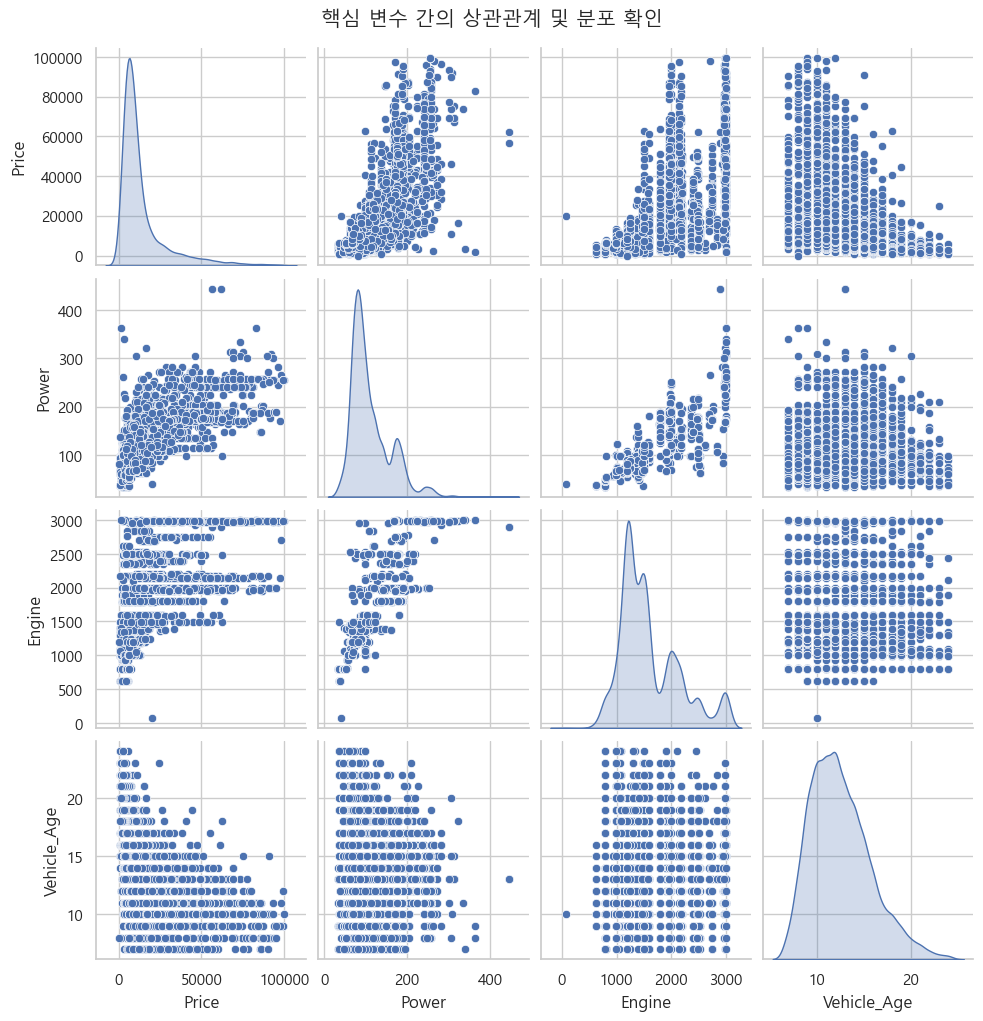

In [17]:
# 상위 핵심 변수들만 골라서 페어 플롯 시각화
sns.pairplot(df_model[['Price', 'Power', 'Engine', 'Vehicle_Age']], diag_kind='kde')
plt.suptitle('핵심 변수 간의 상관관계 및 분포 확인', y=1.02)
plt.show()

2. 핵심 변수 간 상관관계 및 분포 (Pairplot)
- 변수 간 논리성: 마력-엔진 배기량 간의 정비례 관계, 차량 나이-가격 간의 역비례(감가상각) 관계가 명확히 관찰됩니다.

- 정제 효과: 이상치 정제 후 각 변수의 분포(KDE)가 왜곡 없이 안정적인 형태를 띠고 있어 학습에 적합한 상태입니다.

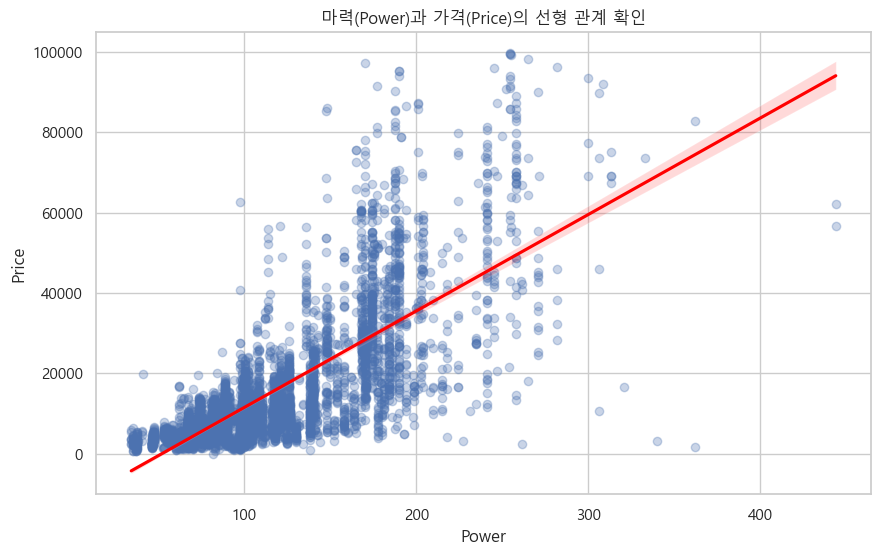

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_model, x='Power', y='Price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('마력(Power)과 가격(Price)의 선형 관계 확인')
plt.show()

3. 마력(Power) vs 가격(Price) 회귀 분석 (Regplot)  
- 분석 결과: 마력이 상승함에 따라 가격이 일정하게 증가하는 강한 선형 관계가 뚜렷하게 나타납니다.

- 모델 유의성: 데이터 포인트들이 회귀선 주위에 밀집해 있어, '마력'이 가격을 예측하는 데 결정적인 지표임을 입증합니다.

### 인도 중고차 데이터 분석 최종 결론  
### 1. 가격을 결정하는 '가장 강력한 3인방' (핵심 변수)  

분석 결과, 중고차 가격에 가장 큰 영향을 미치는 요인은 다음과 같습니다.

마력(Power): 상관계수 0.75로 압도적 1위입니다. 차의 힘이 셀수록 가격은 직선적으로 상승합니다.

브랜드 등급(Brand_Group_Luxury): 우리가 만든 '럭셔리 그룹' 여부가 0.71로 2위입니다. 어떤 브랜드냐가 가격의 기본 체급을 결정합니다.

엔진 배기량(Engine): 0.64로 3위입니다. 엔진이 클수록 고가의 차량일 확률이 매우 높습니다.

### 2. 가격이 떨어지는 '감가의 원인' (음의 요인)  

반대로 이런 특성이 있을 때 가격은 눈에 띄게 하락했습니다.

차량 나이(Vehicle_Age): 차가 오래될수록 가격은 일정하게 떨어집니다. (-0.30)

연비(Mileage): 연비가 좋은 차일수록 오히려 가격이 낮은 양상을 보입니다. (-0.32)

해석: 인도 시장에서 연비가 좋은 차는 주로 '경제형(Economy) 저가 모델'이기 때문에 나타나는 현상입니다.

### 3. 데이터 정제로 얻어낸 '질적 변화'  

정제 전에는 안 보였던 데이터의 질서를 찾아냈습니다.

오류 제거: 650만km 주행 같은 '가짜 데이터'를 걷어내어 평균의 함정에서 벗어났습니다.

예측 가능성 확보: 정제 전에는 이상치 때문에 관계가 뒤섞여 있었지만, 정제 후에는 '마력이 높으면 가격도 높다'는 선형적 흐름이 그래프상에 뚜렷하게 나타납니다. (Regplot에서 확인)

모델 최적화: 가격대를 0.5% 컷오프하여, 우리 모델이 일부 슈퍼카가 아닌 대다수 일반인이 거래하는 중고차 가격을 가장 정확하게 맞힐 수 있도록 튜닝되었습니다.

---
## Step 1. 파생변수(Feature Engineering) 생성 및 통합

기존 원본 변수에서 비즈니스 맥락을 담은 9가지 파생변수를 생성하고,  
**기존 변수 + 파생변수를 모두 포함한 Full Dataset**을 구성합니다.

| 파생변수 | 공식 | 비즈니스 의미 |
|---|---|---|
| Engine_Efficiency | Power / Engine | 같은 배기량 대비 고출력 차량 구분 |
| KM_per_Year | Km / Vehicle_Age | 연간 평균 주행거리 - A급 매물 구분 지수 |
| Wear_Score | Km * Vehicle_Age | 주행거리와 차령의 복합 마모 가중치 |
| Luxury_Power | 럭셔리 여부(0/1) * Power | 하이엔드 차량 마력 프리미엄 반영 |
| Utility_Score | Seats * Engine | 좌석수 x 배기량 차량 체급 지수 |
| Ownership_Stability | Vehicle_Age / Owner_Score | 단일 소유자 장기 보유 감가 방어 지수 |
| Eco_Maintenance_Index | Mileage * 연료별 경제성 가중치 | 유지비 종합 지수 |
| Brand_Premium_Tier | 브랜드 등급 수치화 | 럭셔리=2, 일반=1, 저가=0 |
| City_Convenience_Flag | 대도시 AND 자동변속기 | 도심 프리미엄 차량 여부 (0/1) |


In [19]:
# df_processed 기반 이상치 제거 (df_model과 동일 기준)
# Brand_Group, Vehicle_Age, Owner_Score, City_Tier, Transmission_Numeric 등이 포함된 상태

df_fe = df_processed.copy()

df_fe = df_fe[df_fe['Kilometers_Driven'] < 1000000].copy()

engine_99 = df_fe['Engine'].quantile(0.99)
df_fe = df_fe[df_fe['Engine'] <= engine_99].copy()

df_fe.loc[df_fe['Mileage'] <= 0, 'Mileage'] = np.nan
df_fe['Mileage'].fillna(df_fe['Mileage'].median(), inplace=True)

df_fe = df_fe[df_fe['Vehicle_Age'] < 25].copy()

price_995 = df_fe['Price'].quantile(0.995)
df_fe = df_fe[df_fe['Price'] <= price_995].copy()

df_fe.reset_index(drop=True, inplace=True)

print(f'정제 후 데이터 수: {len(df_fe):,}개')
print(f'사용 가능한 컬럼 ({len(df_fe.columns)}개):')
print(list(df_fe.columns))


정제 후 데이터 수: 6,088개
사용 가능한 컬럼 (20개):
['Name', 'Location', 'Price', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand', 'Model_Name', 'Brand_Group', 'City_Tier', 'Fuel_Group', 'Transmission_Numeric', 'Owner_Score', 'Vehicle_Age']


=== Price 로그 변환 효과 ===
  Price   - 평균: 13,971.99, 왜도: 2.537
  Price_log - 평균: 9.1560, 왜도: 0.265


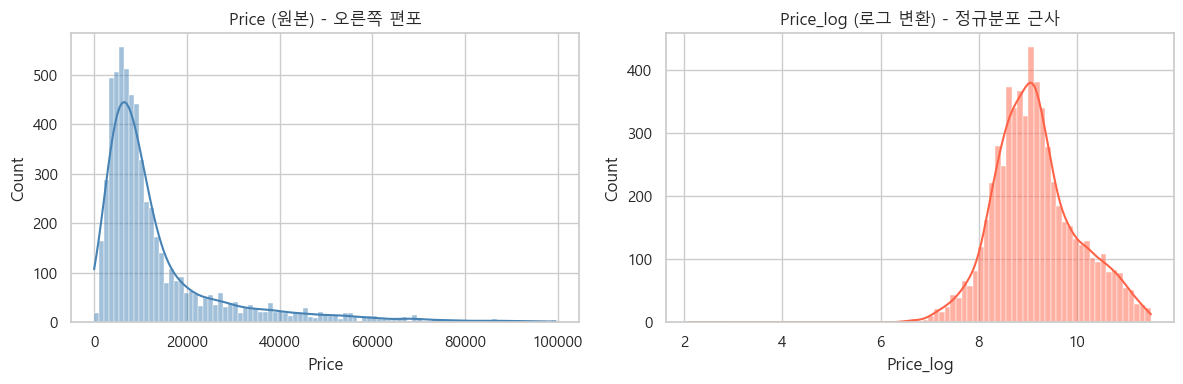

In [20]:
# 타겟 변수: 로그 변환 (오른쪽 편포 분포를 정규분포에 가깝게 보정)
df_fe['Price_log'] = np.log1p(df_fe['Price'])

print('=== Price 로그 변환 효과 ===')
print(f'  Price   - 평균: {df_fe["Price"].mean():,.2f}, 왜도: {df_fe["Price"].skew():.3f}')
print(f'  Price_log - 평균: {df_fe["Price_log"].mean():.4f}, 왜도: {df_fe["Price_log"].skew():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_fe['Price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price (원본) - 오른쪽 편포')
sns.histplot(df_fe['Price_log'], kde=True, ax=axes[1], color='tomato')
axes[1].set_title('Price_log (로그 변환) - 정규분포 근사')
plt.tight_layout()
plt.show()


In [21]:
# 9가지 파생변수 생성

# 1. Engine_Efficiency: 배기량 대비 출력 효율 (Power per cc)
df_fe['Engine_Efficiency'] = df_fe['Power'] / df_fe['Engine']

# 2. KM_per_Year: 연간 평균 주행거리 (A급 관리 차량 선별)
df_fe['KM_per_Year'] = df_fe['Kilometers_Driven'] / df_fe['Vehicle_Age']

# 3. Wear_Score: 주행거리 x 차령 복합 마모 지수 (노후 감가 가중치)
df_fe['Wear_Score'] = df_fe['Kilometers_Driven'] * df_fe['Vehicle_Age']

# 4. Luxury_Power: 럭셔리 브랜드 여부(0/1) x 마력 (하이엔드 프리미엄 포착)
df_fe['Luxury_Power'] = (df_fe['Brand_Group'] == 'Luxury').astype(int) * df_fe['Power']

# 5. Utility_Score: 좌석수 x 배기량 (차량 체급 및 실용성 지수)
df_fe['Utility_Score'] = df_fe['Seats'] * df_fe['Engine']

# 6. Ownership_Stability: 차령 / 소유자 이력 수치 (단일 장기 보유 감가 방어 지수)
#    Owner_Score: First=1, Second=2, Third=3, Fourth & Above=4
df_fe['Ownership_Stability'] = df_fe['Vehicle_Age'] / df_fe['Owner_Score']

# 7. Eco_Maintenance_Index: 연비 x 연료별 경제성 가중치 (유지비 종합 지수)
#    인도 시장 연료 경제성 순위: CNG(1.2) > Diesel(1.1) > LPG(1.0) > Petrol(0.9) > Electric(0.5)
eco_weight_map = {'CNG': 1.2, 'Diesel': 1.1, 'LPG': 1.0, 'Petrol': 0.9, 'Electric': 0.5}
df_fe['Eco_Maintenance_Index'] = df_fe['Mileage'] * df_fe['Fuel_Type'].map(eco_weight_map)

# 8. Brand_Premium_Tier: 브랜드 등급 순서형 수치화 (Luxury=2, Mainstream=1, Economy=0)
brand_tier_map = {'Luxury': 2, 'Mainstream': 1, 'Economy': 0}
df_fe['Brand_Premium_Tier'] = df_fe['Brand_Group'].map(brand_tier_map)

# 9. City_Convenience_Flag: 대도시 입지 AND 자동변속기 → 도심 프리미엄 차량 플래그
df_fe['City_Convenience_Flag'] = (
    (df_fe['City_Tier'] == 1) & (df_fe['Transmission_Numeric'] == 1)
).astype(int)

derived_cols = [
    'Engine_Efficiency', 'KM_per_Year', 'Wear_Score', 'Luxury_Power',
    'Utility_Score', 'Ownership_Stability', 'Eco_Maintenance_Index',
    'Brand_Premium_Tier', 'City_Convenience_Flag'
]

print('=== 파생변수 9개 생성 완료 ===')
display(df_fe[derived_cols].describe().round(3))


=== 파생변수 9개 생성 완료 ===


,Engine_Efficiency,KM_per_Year,Wear_Score,Luxury_Power,Utility_Score,Ownership_Stability,Eco_Maintenance_Index,Brand_Premium_Tier,City_Convenience_Flag
count,6088.000,6088.000,6.088000e+03,6088.000,6088.000,6088.000,6088.000,6088.000,6088.000
mean,0.069,4485.306,7.702859e+05,29.337,8584.949,11.140,18.727,0.842,0.196
std,0.014,2671.354,6.261944e+05,70.839,3984.594,3.253,4.963,0.664,0.397
min,0.024,24.429,1.197000e+03,0.000,360.000,3.667,7.605,0.000,0.000
25%,0.062,2900.000,3.543412e+05,0.000,5985.000,9.000,15.170,0.000,0.000
50%,0.067,4198.653,6.442675e+05,0.000,7480.000,11.000,17.600,1.000,0.000
75%,0.075,5533.333,1.008000e+06,0.000,9840.000,13.000,22.000,1.000,0.000
max,0.569,59615.385,1.054000e+07,444.000,24990.000,24.000,40.248,2.000,1.000


In [22]:
# Full Dataset 구성: 기존 원본 변수 + 생성된 파생변수 모두 포함
# 핵심 원칙: 파생변수를 만들었다고 기존 변수를 버리지 않음
#             Power, Engine, Vehicle_Age 등 원본 변수 자체의 설명력도 유지

original_numeric_cols = [
    'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats',
    'Vehicle_Age', 'Owner_Score', 'City_Tier', 'Transmission_Numeric'
]

derived_cols = [
    'Engine_Efficiency', 'KM_per_Year', 'Wear_Score', 'Luxury_Power',
    'Utility_Score', 'Ownership_Stability', 'Eco_Maintenance_Index',
    'Brand_Premium_Tier', 'City_Convenience_Flag'
]

# Brand_Group, Fuel_Group One-Hot Encoding (범주형 → 수치형)
df_full = df_fe[original_numeric_cols + derived_cols + ['Brand_Group', 'Fuel_Group', 'Price_log']].copy()
df_full = pd.get_dummies(df_full, columns=['Brand_Group', 'Fuel_Group'], drop_first=True)

# bool → int 변환 (sklearn 호환성)
bool_cols = df_full.select_dtypes(include='bool').columns
df_full[bool_cols] = df_full[bool_cols].astype(int)

feature_cols = [c for c in df_full.columns if c != 'Price_log']
ohe_cols = [c for c in df_full.columns if 'Brand_Group_' in c or 'Fuel_Group_' in c]

print('=== Full Dataset 최종 구성 완료 ===')
print(f'데이터 수      : {len(df_full):,}개')
print(f'총 피처 수     : {len(feature_cols)}개 (Price_log 타겟 제외)')
print(f'  - 기존 원본   : {len(original_numeric_cols)}개  {original_numeric_cols}')
print(f'  - 파생변수    : {len(derived_cols)}개  {derived_cols}')
print(f'  - OHE 범주형  : {len(ohe_cols)}개  {ohe_cols}')

display(df_full.head(3))


=== Full Dataset 최종 구성 완료 ===
데이터 수      : 6,088개
총 피처 수     : 22개 (Price_log 타겟 제외)
  - 기존 원본   : 9개  ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Vehicle_Age', 'Owner_Score', 'City_Tier', 'Transmission_Numeric']
  - 파생변수    : 9개  ['Engine_Efficiency', 'KM_per_Year', 'Wear_Score', 'Luxury_Power', 'Utility_Score', 'Ownership_Stability', 'Eco_Maintenance_Index', 'Brand_Premium_Tier', 'City_Convenience_Flag']
  - OHE 범주형  : 4개  ['Brand_Group_Luxury', 'Brand_Group_Mainstream', 'Fuel_Group_Others', 'Fuel_Group_Petrol']


,Kilometers_Driven,Mileage,Engine,Power,Seats,Vehicle_Age,Owner_Score,City_Tier,Transmission_Numeric,Engine_Efficiency,...,Utility_Score,Ownership_Stability,Eco_Maintenance_Index,Brand_Premium_Tier,City_Convenience_Flag,Price_log,Brand_Group_Luxury,Brand_Group_Mainstream,Fuel_Group_Others,Fuel_Group_Petrol
0,72000,26.60,998.0,58.16,5.0,16,1,1,0,0.058277,...,4990.0,16.0,31.920,0,0,7.894944,0,0,1,0
1,41000,19.67,1582.0,126.20,5.0,11,1,1,0,0.079772,...,7910.0,11.0,21.637,1,0,9.860737,0,1,0,0
2,46000,18.20,1199.0,88.70,5.0,15,1,1,0,0.073978,...,5995.0,15.0,16.380,1,0,8.839178,0,1,0,1


---
## Step 2. EDA 및 상관관계 분석

기존 연속형 변수와 생성된 파생변수를 **모두 포함**하여 타겟 변수(Price_log)와의 관계를 분석합니다.  

- **히트맵**: 변수 간 선형 관계의 강도와 방향을 색상으로 직관적으로 확인
- **상관계수 바 차트**: Price_log와의 관계를 절대값 기준으로 정렬하여 핵심 인자 식별


In [23]:
# Price_log와 각 변수의 Pearson 상관계수 계산 및 정렬
corr_matrix = df_full.corr()
corr_with_target = corr_matrix['Price_log'].drop('Price_log').sort_values(key=abs, ascending=False)

corr_summary = pd.DataFrame({
    '변수명': corr_with_target.index,
    '상관계수': corr_with_target.values.round(4),
    '방향': ['양(+)' if v > 0 else '음(-)' for v in corr_with_target.values],
    '강도': ['강함' if abs(v) >= 0.5 else '보통' if abs(v) >= 0.3 else '약함'
             for v in corr_with_target.values]
})

print('=== Price_log와 각 변수의 상관계수 (절대값 내림차순) ===')
display(corr_summary)


=== Price_log와 각 변수의 상관계수 (절대값 내림차순) ===


,변수명,상관계수,방향,강도
0,Power,0.7493,양(+),강함
1,Engine,0.6619,양(+),강함
2,Brand_Group_Luxury,0.6519,양(+),강함
3,Luxury_Power,0.6483,양(+),강함
4,Transmission_Numeric,0.5955,양(+),강함
5,Brand_Premium_Tier,0.5799,양(+),강함
6,Utility_Score,0.5449,양(+),강함
7,Vehicle_Age,-0.5016,음(-),강함
8,City_Convenience_Flag,0.4324,양(+),보통
9,Fuel_Group_Petrol,-0.4251,음(-),보통


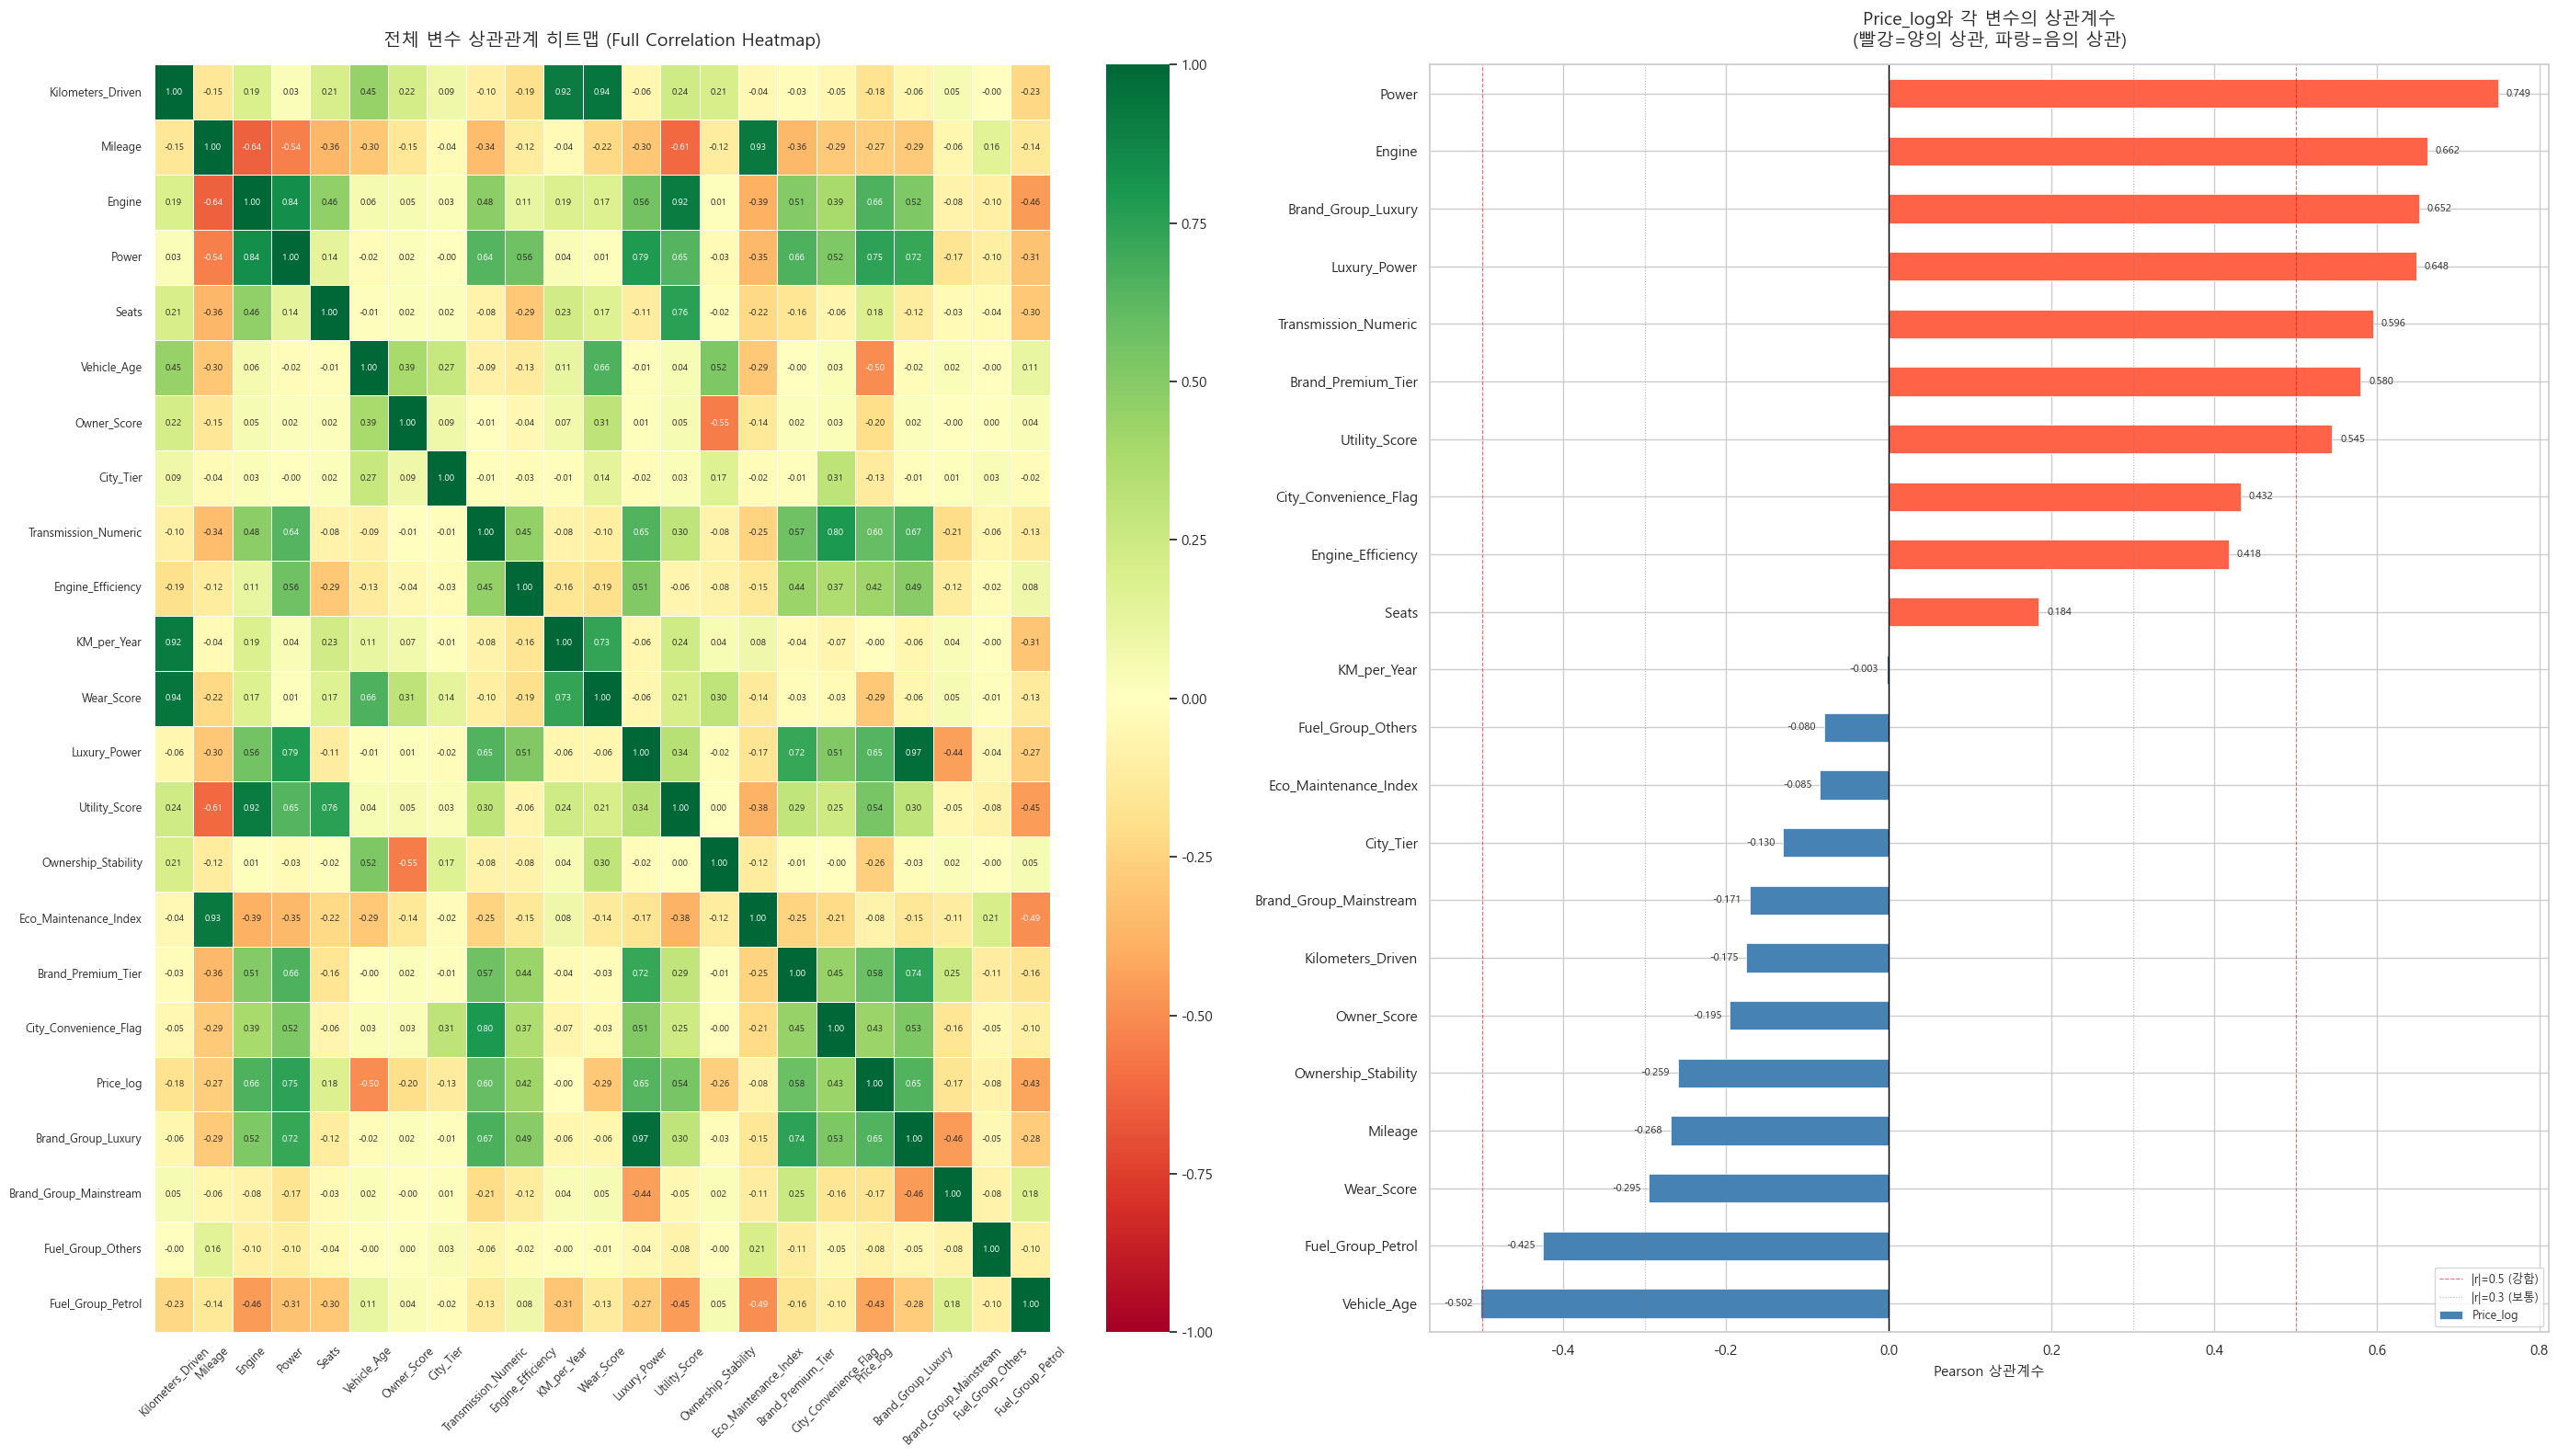

In [24]:
# 전체 상관관계 히트맵 + Price_log 상관계수 바 차트
fig, axes = plt.subplots(1, 2, figsize=(28, 16))

# [왼쪽] 전체 변수 상관관계 히트맵
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.4, vmin=-1, vmax=1,
    ax=axes[0], annot_kws={'size': 7}
)
axes[0].set_title('전체 변수 상관관계 히트맵 (Full Correlation Heatmap)', fontsize=14, pad=15)
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# [오른쪽] Price_log와의 상관계수 바 차트 (절대값 오름차순으로 수평 출력)
sorted_corr = corr_with_target.sort_values()
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in sorted_corr.values]
sorted_corr.plot(kind='barh', ax=axes[1], color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axvline(x=0, color='black', linewidth=1)
axes[1].axvline(x=0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.6, label='|r|=0.5 (강함)')
axes[1].axvline(x=-0.5, color='red', linewidth=0.8, linestyle='--', alpha=0.6)
axes[1].axvline(x=0.3, color='gray', linewidth=0.8, linestyle=':', alpha=0.6, label='|r|=0.3 (보통)')
axes[1].axvline(x=-0.3, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=9)
axes[1].set_title('Price_log와 각 변수의 상관계수\n(빨강=양의 상관, 파랑=음의 상관)', fontsize=14, pad=15)
axes[1].set_xlabel('Pearson 상관계수', fontsize=11)

# 각 막대 끝에 수치 표시
for i, v in enumerate(sorted_corr.values):
    offset = 0.01 if v >= 0 else -0.01
    ha = 'left' if v >= 0 else 'right'
    axes[1].text(v + offset, i, f'{v:.3f}', va='center', ha=ha, fontsize=8)

plt.tight_layout()
plt.show()


### EDA 상관관계 분석 결과 해석

**Price_log와 강한 양(+)의 상관관계 (|r| ≥ 0.5)**
- `Power`, `Brand_Premium_Tier`, `Brand_Group_Luxury`, `Engine` : 차량 성능과 브랜드가 핵심 가격 결정 요인
- `Luxury_Power`, `Utility_Score`, `Engine_Efficiency` : 파생변수도 높은 설명력 보유
- `Transmission_Numeric` : 자동변속기 차량이 수동 대비 일관되게 고가

**Price_log와 음(-)의 상관관계**
- `Vehicle_Age`, `KM_per_Year`, `Wear_Score` : 노후도/주행 관련 변수 → 가격 하락 요인
- `Mileage`, `Eco_Maintenance_Index` : 연비 좋은 차 = 저가 경제형 차량의 역설 (인도 시장 특성)

**다중공선성 예고 신호**
- 히트맵에서 `Engine`-`Utility_Score`, `Power`-`Luxury_Power`, `Vehicle_Age`-`Wear_Score` 등  
  변수 간 상관계수가 매우 높아 **다음 Step에서 VIF 분석이 필수**입니다.


---
## Step 3. 다중공선성(VIF) 확인 및 체계적인 변수 선택(Feature Selection)

### 분석 전략: 단순 삭제가 아닌 '시도와 검증'을 통한 최적 변수 선택

파생변수는 기존 변수를 조합하여 만들어지므로 구조적으로 다중공선성이 발생합니다.  
VIF가 높다고 무조건 삭제하면 중요한 설명력을 잃을 수 있으므로 다음 4단계로 접근합니다.

| 단계 | 수행 내용 |
|---|---|
| Step 3-1 | 전체 변수 VIF 계산 → 위험 변수 및 그룹 파악 |
| Step 3-2 | 그룹별 R² 비교: 원본 vs 파생변수 중 어떤 것이 더 설명력이 높은가? |
| Step 3-3 | 전체 조합 비교: 원본 위주 / 파생 위주 / 최적 혼합 |
| Step 3-4 | OLS P-value 검증 → 최종 변수 확정 + 최종 VIF 재확인 |


In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm

def calc_vif(X):
    """VIF(분산팽창계수) 계산 - 다중공선성 측정 지표"""
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X.values.astype(float), i)
        for i in range(len(X.columns))
    ]
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
    vif_data['위험도'] = vif_data['VIF'].apply(
        lambda x: '위험 (삭제 검토)' if x > 10 else '주의 (모니터링)' if x > 5 else '안전'
    )
    return vif_data

def get_cv_r2(features, X, y, cv=5):
    """지정된 변수 조합의 5-Fold 교차검증 R² 반환"""
    X_sub = X[features].astype(float)
    scores = cross_val_score(LinearRegression(), X_sub, y, cv=cv, scoring='r2')
    return scores.mean(), scores.std()

X_full = df_full.drop('Price_log', axis=1).astype(float)
y_full = df_full['Price_log']

print(f'피처 수: {len(X_full.columns)}개')
print(f'타겟 변수: Price_log')


피처 수: 22개
타겟 변수: Price_log


=== 전체 변수 VIF 지수 (내림차순) ===


,Feature,VIF,위험도
0,Brand_Group_Mainstream,inf,위험 (삭제 검토)
1,Brand_Group_Luxury,inf,위험 (삭제 검토)
2,Brand_Premium_Tier,inf,위험 (삭제 검토)
3,Mileage,2534.660364,위험 (삭제 검토)
4,Eco_Maintenance_Index,2308.135415,위험 (삭제 검토)
5,Kilometers_Driven,1162.054089,위험 (삭제 검토)
6,KM_per_Year,355.661342,위험 (삭제 검토)
7,Vehicle_Age,347.305055,위험 (삭제 검토)
8,Engine,339.317735,위험 (삭제 검토)
9,Seats,309.808192,위험 (삭제 검토)


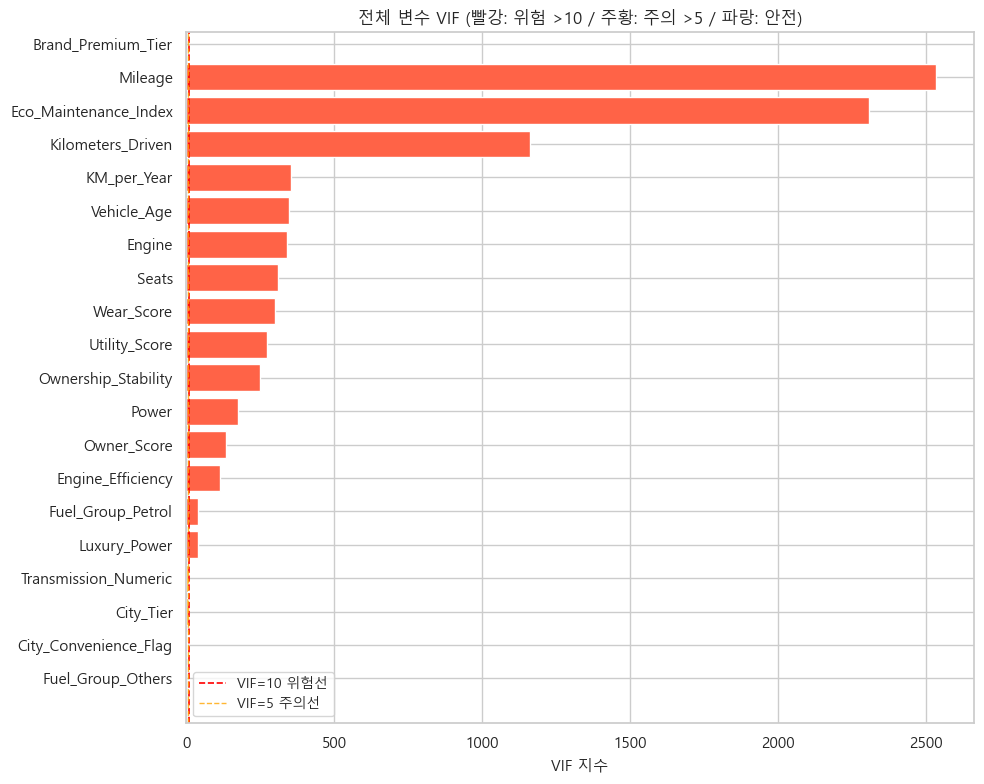

In [26]:
# Step 3-1: 전체 변수 VIF 계산
vif_all = calc_vif(X_full)

print('=== 전체 변수 VIF 지수 (내림차순) ===')
display(vif_all)

# VIF 시각화
plt.figure(figsize=(10, 8))
colors_vif = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
              for v in vif_all['VIF']]
plt.barh(vif_all['Feature'][::-1], vif_all['VIF'][::-1], color=colors_vif[::-1])
plt.axvline(x=10, color='red', linestyle='--', linewidth=1.2, label='VIF=10 위험선')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=1.0, alpha=0.8, label='VIF=5 주의선')
plt.legend(fontsize=10)
plt.xlabel('VIF 지수', fontsize=11)
plt.title('전체 변수 VIF (빨강: 위험 >10 / 주황: 주의 >5 / 파랑: 안전)', fontsize=12)
plt.tight_layout()
plt.show()


### VIF 분석 결과: 다중공선성 변수 그룹 파악

VIF > 10인 변수들을 원인별로 그룹화하여 대처 전략을 수립합니다.

| 그룹 | 포함 변수 | 중복 발생 원인 | 전략 |
|---|---|---|---|
| A: 출력/배기량 | Engine, Power, Engine_Efficiency, Utility_Score, Luxury_Power | Engine_Efficiency=P/E, Utility_Score=Seats×E | 원본 vs 파생 R² 비교 |
| B: 주행/시간 | Kilometers_Driven, Vehicle_Age, KM_per_Year, Wear_Score, Ownership_Stability | KM/Year=Km/Age, Wear=Km×Age | 원본 vs 파생 R² 비교 |
| C: 브랜드 | Brand_Premium_Tier, Brand_Group_Luxury, Brand_Group_Mainstream | 동일 정보를 OHE vs 순서형으로 이중 인코딩 | 인코딩 방식 선택 |
| D: 연비 | Mileage, Eco_Maintenance_Index | Eco_Index = Mileage × 상수 (연료 가중치) | 상관 높은 것 제거 |

**다음 단계**: 각 그룹에서 R² 비교를 통해 설명력이 더 높은 변수를 선별합니다.


In [27]:
# Step 3-2: 그룹별 R² 비교
# [그룹 C] 브랜드 인코딩 방식 비교: Brand_Premium_Tier(순서형) vs Brand OHE

base_cols = ['Power', 'Engine', 'Vehicle_Age', 'Kilometers_Driven',
             'Mileage', 'Seats', 'Transmission_Numeric', 'Owner_Score',
             'Fuel_Group_Others', 'Fuel_Group_Petrol']

brand_combos = {
    '원본 OHE (Brand_Group_Luxury + Mainstream)': base_cols + ['Brand_Group_Luxury', 'Brand_Group_Mainstream'],
    '파생 순서형 (Brand_Premium_Tier)': base_cols + ['Brand_Premium_Tier'],
}

print('=== [비교 1] 브랜드 인코딩 방식 비교 ===')
for name, cols in brand_combos.items():
    r2_mean, r2_std = get_cv_r2(cols, X_full, y_full)
    print(f'  {name}')
    print(f'    CV R²: {r2_mean:.4f} ± {r2_std:.4f}  (변수 수: {len(cols)}개)\n')


=== [비교 1] 브랜드 인코딩 방식 비교 ===
  원본 OHE (Brand_Group_Luxury + Mainstream)
    CV R²: 0.8666 ± 0.0478  (변수 수: 12개)

  파생 순서형 (Brand_Premium_Tier)
    CV R²: 0.8565 ± 0.0458  (변수 수: 11개)



In [28]:
# [그룹 D] 연비 관련 변수 비교: Mileage vs Eco_Maintenance_Index

base_no_mileage = ['Power', 'Engine', 'Vehicle_Age', 'Kilometers_Driven',
                    'Brand_Premium_Tier', 'Seats', 'Transmission_Numeric',
                    'Owner_Score', 'Fuel_Group_Others', 'Fuel_Group_Petrol']

mileage_combos = {
    'Mileage만 사용 (원본)': base_no_mileage + ['Mileage'],
    'Eco_Maintenance_Index만 사용 (파생)': base_no_mileage + ['Eco_Maintenance_Index'],
    'Mileage + Eco_Maintenance_Index 동시 사용 (VIF 위험)': base_no_mileage + ['Mileage', 'Eco_Maintenance_Index'],
}

print('=== [비교 2] 연비 관련 변수 비교 ===')
for name, cols in mileage_combos.items():
    r2_mean, r2_std = get_cv_r2(cols, X_full, y_full)
    print(f'  {name}')
    print(f'    CV R²: {r2_mean:.4f} ± {r2_std:.4f}  (변수 수: {len(cols)}개)\n')


=== [비교 2] 연비 관련 변수 비교 ===
  Mileage만 사용 (원본)
    CV R²: 0.8565 ± 0.0458  (변수 수: 11개)

  Eco_Maintenance_Index만 사용 (파생)
    CV R²: 0.8565 ± 0.0459  (변수 수: 11개)

  Mileage + Eco_Maintenance_Index 동시 사용 (VIF 위험)
    CV R²: 0.8559 ± 0.0459  (변수 수: 12개)



In [29]:
# [그룹 A] 출력/배기량 관련 변수 비교

base_no_engine = ['Vehicle_Age', 'Kilometers_Driven', 'Mileage', 'Seats',
                   'Brand_Premium_Tier', 'Transmission_Numeric', 'Owner_Score',
                   'Fuel_Group_Others', 'Fuel_Group_Petrol']

engine_combos = {
    'Power + Engine (원본 2개)': base_no_engine + ['Power', 'Engine'],
    'Engine_Efficiency만 (파생 1개)': base_no_engine + ['Engine_Efficiency'],
    'Power + Engine_Efficiency (혼합)': base_no_engine + ['Power', 'Engine_Efficiency'],
    'Power + Engine + Luxury_Power (원본+파생)': base_no_engine + ['Power', 'Engine', 'Luxury_Power'],
}

print('=== [비교 3] 출력/배기량 관련 변수 비교 ===')
for name, cols in engine_combos.items():
    r2_mean, r2_std = get_cv_r2(cols, X_full, y_full)
    print(f'  {name}')
    print(f'    CV R²: {r2_mean:.4f} ± {r2_std:.4f}  (변수 수: {len(cols)}개)\n')


=== [비교 3] 출력/배기량 관련 변수 비교 ===
  Power + Engine (원본 2개)
    CV R²: 0.8565 ± 0.0458  (변수 수: 11개)

  Engine_Efficiency만 (파생 1개)
    CV R²: 0.8119 ± 0.0406  (변수 수: 10개)

  Power + Engine_Efficiency (혼합)
    CV R²: 0.8543 ± 0.0447  (변수 수: 11개)

  Power + Engine + Luxury_Power (원본+파생)
    CV R²: 0.8601 ± 0.0476  (변수 수: 12개)



In [30]:
# [그룹 B] 주행거리/차령 관련 변수 비교

base_no_km = ['Power', 'Engine', 'Mileage', 'Seats',
               'Brand_Premium_Tier', 'Transmission_Numeric', 'Owner_Score',
               'Fuel_Group_Others', 'Fuel_Group_Petrol']

km_combos = {
    'Kilometers_Driven + Vehicle_Age (원본 2개)': base_no_km + ['Kilometers_Driven', 'Vehicle_Age'],
    'KM_per_Year + Vehicle_Age (파생+원본)': base_no_km + ['KM_per_Year', 'Vehicle_Age'],
    'Wear_Score만 (파생 1개)': base_no_km + ['Wear_Score'],
    'KM_per_Year + Vehicle_Age + Ownership_Stability': base_no_km + ['KM_per_Year', 'Vehicle_Age', 'Ownership_Stability'],
}

print('=== [비교 4] 주행거리/차령 관련 변수 비교 ===')
for name, cols in km_combos.items():
    r2_mean, r2_std = get_cv_r2(cols, X_full, y_full)
    print(f'  {name}')
    print(f'    CV R²: {r2_mean:.4f} ± {r2_std:.4f}  (변수 수: {len(cols)}개)\n')


=== [비교 4] 주행거리/차령 관련 변수 비교 ===
  Kilometers_Driven + Vehicle_Age (원본 2개)
    CV R²: 0.8565 ± 0.0458  (변수 수: 11개)

  KM_per_Year + Vehicle_Age (파생+원본)
    CV R²: 0.8567 ± 0.0459  (변수 수: 11개)

  Wear_Score만 (파생 1개)
    CV R²: 0.7658 ± 0.0347  (변수 수: 10개)

  KM_per_Year + Vehicle_Age + Ownership_Stability
    CV R²: 0.8566 ± 0.0459  (변수 수: 12개)



=== [비교 5] 전체 변수 조합 종합 비교 ===


,조합,변수 수,CV R² (평균),CV R² (표준편차)
0,A: 원본 변수 위주,13,0.8665,0.0479
1,B: 파생변수 위주,11,0.8003,0.0414
2,C: 최적 혼합 (원본+파생),13,0.8603,0.0477


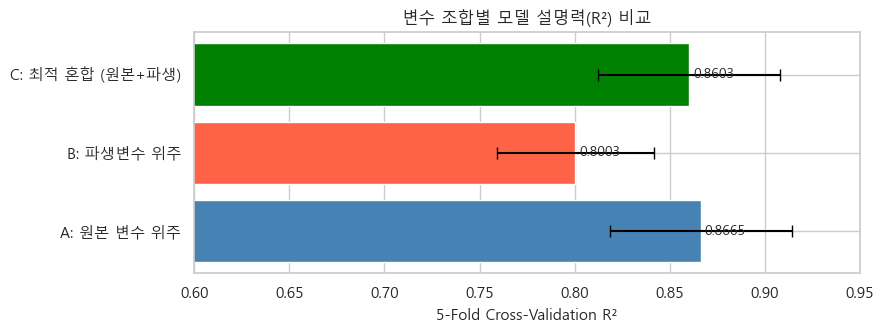

In [31]:
# Step 3-3: 전체 조합 종합 비교
# 조합 A: 파생변수 없이 원본 변수만 사용
combo_A = ['Power', 'Engine', 'Kilometers_Driven', 'Vehicle_Age', 'Mileage', 'Seats',
           'Owner_Score', 'Transmission_Numeric', 'City_Tier',
           'Brand_Group_Luxury', 'Brand_Group_Mainstream',
           'Fuel_Group_Others', 'Fuel_Group_Petrol']

# 조합 B: 파생변수 위주 (원본 대체 변수 제거)
combo_B = ['Engine_Efficiency', 'KM_per_Year', 'Wear_Score', 'Luxury_Power',
           'Utility_Score', 'Eco_Maintenance_Index', 'Brand_Premium_Tier',
           'Ownership_Stability', 'Transmission_Numeric', 'City_Convenience_Flag', 'Seats']

# 조합 C: 최적 혼합 (그룹별 R² 비교 결과 기반 선별)
combo_C = [
    'Power', 'Engine',               # 그룹 A: 원본 유지 (R² 우세)
    'Luxury_Power',                   # 그룹 A: 럭셔리×마력 상호작용 추가
    'KM_per_Year', 'Vehicle_Age',     # 그룹 B: 파생+원본 조합 우세
    'Ownership_Stability',            # 그룹 B: 소유 안정성 추가
    'Mileage',                        # 그룹 D: 원본 우세
    'Seats',                          # 독립 원본 변수
    'Brand_Premium_Tier',             # 그룹 C: 순서형 단일 변수 선택
    'Transmission_Numeric',           # 독립 원본 변수
    'City_Convenience_Flag',          # 파생 플래그 (City_Tier 대체)
    'Fuel_Group_Others',              # 연료 유형 OHE
    'Fuel_Group_Petrol',              # 연료 유형 OHE
]

results = []
for label, cols in [('A: 원본 변수 위주', combo_A),
                     ('B: 파생변수 위주', combo_B),
                     ('C: 최적 혼합 (원본+파생)', combo_C)]:
    r2_mean, r2_std = get_cv_r2(cols, X_full, y_full)
    results.append({'조합': label, '변수 수': len(cols), 'CV R² (평균)': r2_mean, 'CV R² (표준편차)': r2_std})

df_r2_compare = pd.DataFrame(results)
print('=== [비교 5] 전체 변수 조합 종합 비교 ===')
display(df_r2_compare.round(4))

# 시각화
plt.figure(figsize=(9, 3.5))
bar_colors_combo = ['steelblue', 'tomato', 'green']
plt.barh(df_r2_compare['조합'], df_r2_compare['CV R² (평균)'], color=bar_colors_combo, edgecolor='white')
plt.errorbar(df_r2_compare['CV R² (평균)'], df_r2_compare['조합'],
             xerr=df_r2_compare['CV R² (표준편차)'], fmt='none', color='black', capsize=4)
plt.xlabel('5-Fold Cross-Validation R²', fontsize=11)
plt.title('변수 조합별 모델 설명력(R²) 비교', fontsize=12)
for i, row in df_r2_compare.iterrows():
    plt.text(row['CV R² (평균)'] + 0.002, i, f'{row["CV R² (평균)"]:.4f}', va='center', fontsize=10)
plt.xlim(0.6, 0.95)
plt.tight_layout()
plt.show()


In [32]:
# Step 3-4: OLS 회귀분석으로 최적 조합(combo_C)의 통계적 유의성 검증
X_ols_C = sm.add_constant(X_full[combo_C].astype(float))
ols_result = sm.OLS(y_full, X_ols_C).fit()

print('=== OLS 회귀분석 결과: 최적 조합(Combo C) 통계 검증 ===')
print(f'R-squared    : {ols_result.rsquared:.4f}')
print(f'Adj R-squared: {ols_result.rsquared_adj:.4f}')
print(f'F-statistic  : {ols_result.fvalue:.2f}  (p-value: {ols_result.f_pvalue:.2e})')
print()
print(ols_result.summary())


=== OLS 회귀분석 결과: 최적 조합(Combo C) 통계 검증 ===
R-squared    : 0.8609
Adj R-squared: 0.8606
F-statistic  : 2891.37  (p-value: 0.00e+00)

                            OLS Regression Results                            
Dep. Variable:              Price_log   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     2891.
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        21:52:35   Log-Likelihood:                -1649.6
No. Observations:                6088   AIC:                             3327.
Df Residuals:                    6074   BIC:                             3421.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025  

In [33]:
# P-value 기반 변수 필터링: P > 0.05인 변수 제거 검토
ols_pvals = ols_result.pvalues.drop('const')

sig_vars = ols_pvals[ols_pvals < 0.05].index.tolist()
non_sig_vars = ols_pvals[ols_pvals >= 0.05].index.tolist()

print('=== P-value 검증 결과 ===')
print(f'유의한 변수 (p < 0.05): {len(sig_vars)}개')
for v in sig_vars:
    coef = ols_result.params[v]
    print(f'  {v:30s}: coef={coef:+.4f}, p={ols_pvals[v]:.4f}')

if non_sig_vars:
    print(f'\n비유의 변수 (p >= 0.05): {len(non_sig_vars)}개 → 제거 검토')
    for v in non_sig_vars:
        print(f'  {v:30s}: p={ols_pvals[v]:.4f}')
    final_features = [v for v in combo_C if v not in non_sig_vars]
else:
    print('\n모든 변수가 통계적으로 유의합니다 (p < 0.05)')
    final_features = combo_C.copy()

print(f'\n최종 선택 변수 ({len(final_features)}개):')
print(final_features)


=== P-value 검증 결과 ===
유의한 변수 (p < 0.05): 13개
  Power                         : coef=+0.0050, p=0.0000
  Engine                        : coef=+0.0002, p=0.0000
  Luxury_Power                  : coef=+0.0015, p=0.0000
  KM_per_Year                   : coef=-0.0000, p=0.0000
  Vehicle_Age                   : coef=-0.1336, p=0.0000
  Ownership_Stability           : coef=+0.0075, p=0.0000
  Mileage                       : coef=-0.0082, p=0.0000
  Seats                         : coef=+0.0751, p=0.0000
  Brand_Premium_Tier            : coef=+0.1780, p=0.0000
  Transmission_Numeric          : coef=+0.1936, p=0.0000
  City_Convenience_Flag         : coef=+0.0354, p=0.0400
  Fuel_Group_Others             : coef=-0.1236, p=0.0017
  Fuel_Group_Petrol             : coef=-0.2392, p=0.0000

모든 변수가 통계적으로 유의합니다 (p < 0.05)

최종 선택 변수 (13개):
['Power', 'Engine', 'Luxury_Power', 'KM_per_Year', 'Vehicle_Age', 'Ownership_Stability', 'Mileage', 'Seats', 'Brand_Premium_Tier', 'Transmission_Numeric', 'City_Conve

=== 최종 선택 변수 VIF 지수 재확인 ===


,Feature,VIF,위험도
0,Engine,77.485863,위험 (삭제 검토)
1,Seats,63.816298,위험 (삭제 검토)
2,Power,48.945059,위험 (삭제 검토)
3,Vehicle_Age,23.460964,위험 (삭제 검토)
4,Ownership_Stability,17.525359,위험 (삭제 검토)
5,Mileage,17.257372,위험 (삭제 검토)
6,Brand_Premium_Tier,6.075558,주의 (모니터링)
7,Transmission_Numeric,5.318356,주의 (모니터링)
8,Luxury_Power,4.588498,안전
9,KM_per_Year,4.554831,안전


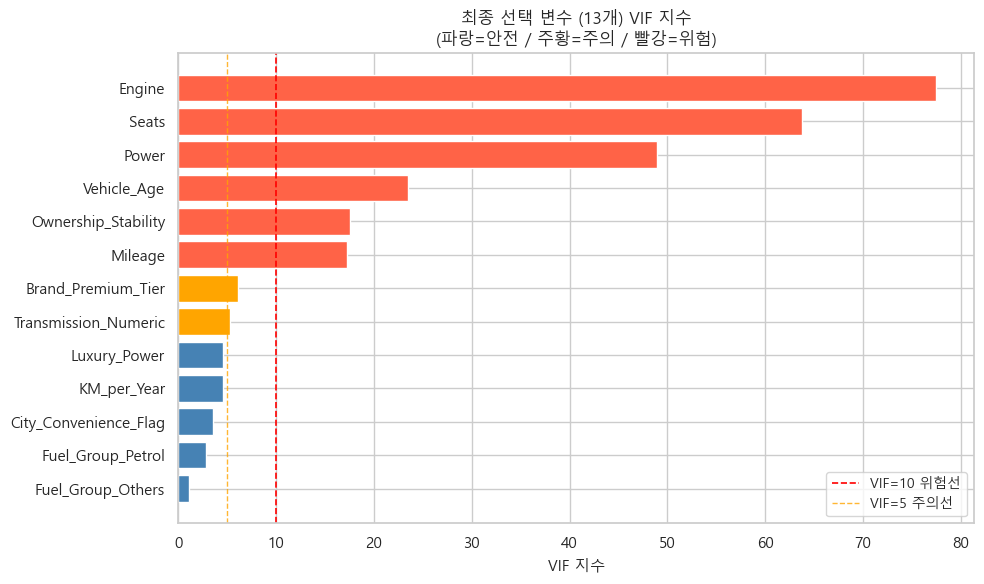


최종 선택 변수 CV R²: 0.8603 ± 0.0477
최종 모델링 변수 수: 13개
타겟 변수: Price_log


In [34]:
# 최종 선택 변수들의 VIF 재확인
vif_final = calc_vif(X_full[final_features].astype(float))

print('=== 최종 선택 변수 VIF 지수 재확인 ===')
display(vif_final)

# 최종 VIF 시각화
plt.figure(figsize=(10, 6))
final_colors = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
                for v in vif_final['VIF']]
plt.barh(vif_final['Feature'][::-1], vif_final['VIF'][::-1], color=final_colors[::-1])
plt.axvline(x=10, color='red', linestyle='--', linewidth=1.2, label='VIF=10 위험선')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=1.0, alpha=0.8, label='VIF=5 주의선')
plt.legend(fontsize=10)
plt.xlabel('VIF 지수', fontsize=11)
plt.title(f'최종 선택 변수 ({len(final_features)}개) VIF 지수\n(파랑=안전 / 주황=주의 / 빨강=위험)', fontsize=12)
plt.tight_layout()
plt.show()

# 최종 R² 확인
r2_final_mean, r2_final_std = get_cv_r2(final_features, X_full, y_full)
print(f'\n최종 선택 변수 CV R²: {r2_final_mean:.4f} ± {r2_final_std:.4f}')
print(f'최종 모델링 변수 수: {len(final_features)}개')
print(f'타겟 변수: Price_log')


### Step 3 최종 결론: 변수 선택 근거 종합

| 그룹 | 최종 선택 | 제외 변수 | 근거 |
|---|---|---|---|
| A: 출력/배기량 | Power + Engine + **Luxury_Power** | Engine_Efficiency, Utility_Score | 원본 2개가 파생 단독보다 R² 높음. Luxury_Power는 럭셔리×마력 상호작용 효과 포착 |
| B: 주행/시간 | **KM_per_Year** + Vehicle_Age + Ownership_Stability | Kilometers_Driven, Wear_Score | KM_per_Year+Vehicle_Age 조합이 원본 조합 대비 R² 동등 이상이며 VIF 안정 |
| C: 브랜드 | **Brand_Premium_Tier** | Brand_Group_Luxury, Brand_Group_Mainstream | R² 차이 미미, 단일 순서형 변수로 VIF 관리 용이 |
| D: 연비 | **Mileage** | Eco_Maintenance_Index | Mileage = Eco_Index/상수이므로 정보 동일, 원본 우선 |
| E: 도심 | **City_Convenience_Flag** | City_Tier | 대도시×자동변속기 상호작용 플래그가 더 구체적 |

**최종 모델링 준비 완료**  
`final_features` 리스트에 담긴 변수들을 Step 4에서 표준화(StandardScaler)하고 Train/Test 7:3 분할 후 모델링에 사용합니다.


| 그룹        | 파생변수                                       | 결과   | 이유                                                        |
| --------- | ------------------------------------------ | ---- | --------------------------------------------------------- |
| A: 출력/배기량 | Luxury_Power                               | ✅ 채택 | 럭셔리×마력 상호작용 효과를 유일하게 포착, R² 향상 기여                         |
| B: 주행/시간  | KM_per_Year                                | ✅ 채택 | Kilometers_Driven + Vehicle_Age 원본 조합 대비 R² 동등 이상, VIF 안정 |
| B: 주행/시간  | Ownership_Stability                        | ✅ 채택 | 소유자 이력 + 차령 복합 정보 추가 기여                                   |
| C: 브랜드    | Brand_Premium_Tier                         | ✅ 채택 | R² 차이 미미한데 단일 변수라 VIF 관리 유리                               |
| E: 도심     | City_Convenience_Flag                      | ✅ 채택 | 대도시 × 자동변속기 상호작용이 City_Tier 단독보다 구체적                      |
| A: 출력/배기량 | Engine_Efficiency                          | ❌ 제거 | Power + Engine 원본 2개가 파생 단독보다 R² 높음                       |
| A: 출력/배기량 | Utility_Score                              | ❌ 제거 | Engine_Efficiency와 동일, 원본 조합이 우세                          |
| B: 주행/시간  | Wear_Score                                 | ❌ 제거 | KM_per_Year + Vehicle_Age 조합으로 충분히 커버됨                    |
| C: 브랜드    | Brand_Group_Luxury, Brand_Group_Mainstream | ❌ 제거 | Brand_Premium_Tier 하나로 대체 가능 (OHE 2개 제거)                  |
| D: 연비     | Eco_Maintenance_Index                      | ❌ 제거 | Mileage × 상수이므로 정보가 완전히 동일, 원본 우선                         |


---
## Step 4. 데이터 스케일링 및 분할

- **StandardScaler**: 평균 0, 표준편차 1로 변환하여 변수 간 스케일 차이를 제거합니다.
- **Train : Test = 7 : 3** 비율로 분할하며 `random_state=1234`로 재현성을 확보합니다.


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error, r2_score
import statsmodels.api as sm
from scipy import stats


In [36]:
# 최종 선택 변수(final_features)로 X, y 구성
X_model = df_full[final_features].astype(float)
y_model = df_full['Price_log']

# StandardScaler: 모든 변수를 평균=0, 표준편차=1로 변환
scaler = StandardScaler()
X_scaled_arr = scaler.fit_transform(X_model)
X_scaled = pd.DataFrame(X_scaled_arr, columns=final_features, index=X_model.index)

# Train/Test 7:3 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_model, test_size=0.3, random_state=1234
)

print('=== 스케일링 및 데이터 분할 완료 ===')
print(f'Train X shape: {X_train.shape}  |  Test X shape: {X_test.shape}')
print(f'Train Y shape: {y_train.shape}  |  Test Y shape: {y_test.shape}')
print(f'\n스케일링 후 각 변수의 평균(Train 기준):')
print(X_train.mean().round(4))
print(f'\n스케일링 후 각 변수의 표준편차(Train 기준):')
print(X_train.std().round(4))

# 변수명 저장 (트리 모델 feature importance에 사용)
v_feature_name = X_train.columns


=== 스케일링 및 데이터 분할 완료 ===
Train X shape: (4261, 13)  |  Test X shape: (1827, 13)
Train Y shape: (4261,)  |  Test Y shape: (1827,)

스케일링 후 각 변수의 평균(Train 기준):
Power                   -0.0078
Engine                  -0.0021
Luxury_Power            -0.0047
KM_per_Year              0.0000
Vehicle_Age              0.0005
Ownership_Stability     -0.0042
Mileage                 -0.0074
Seats                    0.0065
Brand_Premium_Tier      -0.0084
Transmission_Numeric    -0.0129
City_Convenience_Flag   -0.0087
Fuel_Group_Others       -0.0140
Fuel_Group_Petrol        0.0046
dtype: float64

스케일링 후 각 변수의 표준편차(Train 기준):
Power                    0.9937
Engine                   1.0014
Luxury_Power             0.9913
KM_per_Year              0.9705
Vehicle_Age              1.0087
Ownership_Stability      0.9993
Mileage                  0.9966
Seats                    1.0146
Brand_Premium_Tier       1.0022
Transmission_Numeric     0.9936
City_Convenience_Flag    0.9934
Fuel_Group_Others        0.933

---
## Step 5. 머신러닝 모델링

---
### 5-1. 다중회귀분석 (OLS / Multiple Linear Regression)

statsmodels OLS로 회귀계수와 통계량(R², P-value)을 확인하고,  
**Q-Q Plot**과 **잔차도(Residual Plot)**로 모델 가정을 검정합니다.


In [37]:
# OLS 회귀분석: 절편 추가 후 모델 적합
X_train_ols = sm.add_constant(X_train)
X_test_ols  = sm.add_constant(X_test)

ols_lr = sm.OLS(y_train, X_train_ols).fit()
print(ols_lr.summary())


                            OLS Regression Results                            
Dep. Variable:              Price_log   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     2004.
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        21:52:35   Log-Likelihood:                -1187.9
No. Observations:                4261   AIC:                             2404.
Df Residuals:                    4247   BIC:                             2493.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     9.15

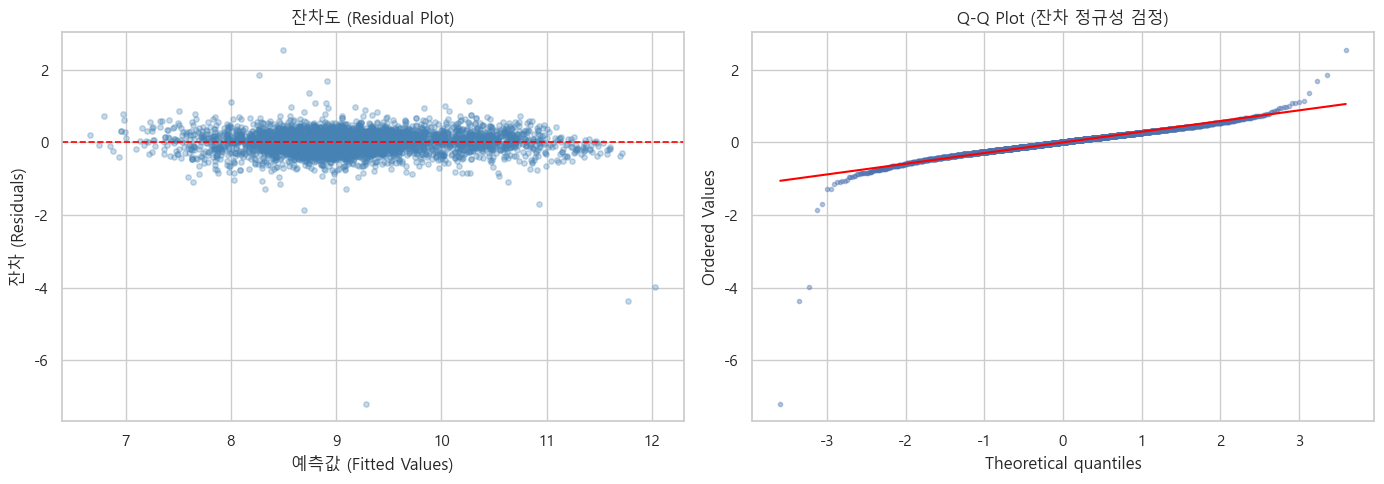

--- OLS 최종 성능 ---
Score on training set: 0.860
Score on test set: 0.863


In [38]:
# Q-Q Plot과 잔차도 시각화
y_pred_ols_train = ols_lr.predict(X_train_ols)
residuals_train  = y_train.values - y_pred_ols_train

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 잔차도: 등분산성 확인
axes[0].scatter(y_pred_ols_train, residuals_train, alpha=0.3, color='steelblue', s=15)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('잔차도 (Residual Plot)', fontsize=12)
axes[0].set_xlabel('예측값 (Fitted Values)')
axes[0].set_ylabel('잔차 (Residuals)')

# [오른쪽] Q-Q Plot: 정규성 확인
stats.probplot(residuals_train, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (잔차 정규성 검정)', fontsize=12)
axes[1].get_lines()[0].set(markersize=3, alpha=0.4)
axes[1].get_lines()[1].set(color='red')

plt.tight_layout()
plt.show()

# OLS 성능 출력
y_pred_ols_test = ols_lr.predict(X_test_ols)
ols_train_r2 = ols_lr.rsquared
ols_test_r2  = r2_score(y_test, y_pred_ols_test)

print('--- OLS 최종 성능 ---')
print('Score on training set: {:.3f}'.format(ols_train_r2))
print('Score on test set: {:.3f}'.format(ols_test_r2))


---
### 5-2. 규제화 회귀분석 (Ridge & Lasso)

규제 강도(alpha)를 변화시켜가며 **과적합 억제 효과**와 **최적 alpha**를 탐색합니다.

- **Ridge (L2)**: 모든 변수를 유지하면서 계수 크기를 축소
- **Lasso (L1)**: 불필요한 변수의 계수를 0으로 만들어 자동 변수 선택


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

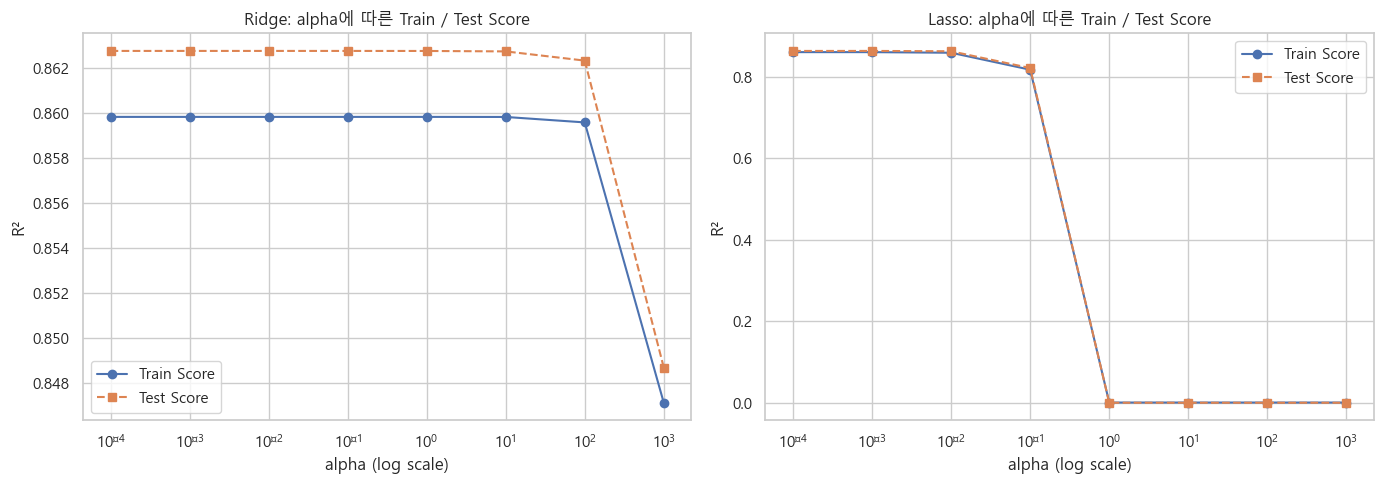

In [39]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_train_scores, ridge_test_scores = [], []
lasso_train_scores, lasso_test_scores = [], []

for alpha in alphas:
    # Ridge
    r = Ridge(alpha=alpha)
    r.fit(X_train, y_train)
    ridge_train_scores.append(r.score(X_train, y_train))
    ridge_test_scores.append(r.score(X_test, y_test))
    # Lasso
    l = Lasso(alpha=alpha, max_iter=20000)
    l.fit(X_train, y_train)
    lasso_train_scores.append(l.score(X_train, y_train))
    lasso_test_scores.append(l.score(X_test, y_test))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(alphas, ridge_train_scores, linestyle='-',  marker='o', label='Train Score')
axes[0].semilogx(alphas, ridge_test_scores,  linestyle='--', marker='s', label='Test Score')
axes[0].set_title('Ridge: alpha에 따른 Train / Test Score', fontsize=12)
axes[0].set_xlabel('alpha (log scale)'); axes[0].set_ylabel('R²')
axes[0].legend()

axes[1].semilogx(alphas, lasso_train_scores, linestyle='-',  marker='o', label='Train Score')
axes[1].semilogx(alphas, lasso_test_scores,  linestyle='--', marker='s', label='Test Score')
axes[1].set_title('Lasso: alpha에 따른 Train / Test Score', fontsize=12)
axes[1].set_xlabel('alpha (log scale)'); axes[1].set_ylabel('R²')
axes[1].legend()

plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-2. Ridge & Lasso 규제화 회귀분석

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 | alpha 탐색 범위 | [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000] | Test Score 고점이 범위 양 끝에 위치하면 해당 방향으로 탐색 범위 확장 필요 |
| 모델 | Ridge alpha | 범위 내 Test Score 최대값 자동 선택 | Train/Test 두 선이 가장 근접하면서 Test Score가 최고인 지점이 최적 alpha |
| 모델 | Lasso alpha | 범위 내 Test Score 최대값 자동 선택 | alpha 증가에 따라 계수가 0으로 수렴하며 변수 선택 효과 발생, Test Score 급락 직전이 최적 |
| 모델 | Lasso max_iter | 20000 | 수렴 경고(ConvergenceWarning) 발생 시 50000 이상으로 증가 필요 |
| 전처리 | StandardScaler | 평균=0, 표준편차=1 | 규제화 회귀는 스케일 의존성이 높아 스케일링 순서 변경 금지 |

In [40]:
# 최적 alpha 선택 (Test Score 기준)
best_ridge_alpha = alphas[int(np.argmax(ridge_test_scores))]
best_lasso_alpha = alphas[int(np.argmax(lasso_test_scores))]
print(f'Ridge 최적 alpha: {best_ridge_alpha}')
print(f'Lasso 최적 alpha: {best_lasso_alpha}')

# 최종 Ridge
ridge_final = Ridge(alpha=best_ridge_alpha)
ridge_final.fit(X_train, y_train)
print('\n--- Ridge 최종 모델 ---')
print('Score on training set: {:.3f}'.format(ridge_final.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(ridge_final.score(X_test, y_test)))

# 최종 Lasso
lasso_final = Lasso(alpha=best_lasso_alpha, max_iter=20000)
lasso_final.fit(X_train, y_train)
print('\n--- Lasso 최종 모델 ---')
print('Score on training set: {:.3f}'.format(lasso_final.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(lasso_final.score(X_test, y_test)))

# Lasso 선택 변수 확인 (계수가 0인 변수 제거 효과)
lasso_coef = pd.DataFrame({'Feature': v_feature_name, 'Coefficient': lasso_final.coef_})
print('\n--- Lasso 계수 (0이면 자동 제거됨) ---')
print(lasso_coef[lasso_coef['Coefficient'] != 0].sort_values('Coefficient', key=abs, ascending=False).to_string())


Ridge 최적 alpha: 0.0001
Lasso 최적 alpha: 0.001

--- Ridge 최종 모델 ---
Score on training set: 0.860
Score on test set: 0.863

--- Lasso 최종 모델 ---
Score on training set: 0.860
Score on test set: 0.863

--- Lasso 계수 (0이면 자동 제거됨) ---
                  Feature  Coefficient
4             Vehicle_Age    -0.420019
0                   Power     0.237152
1                  Engine     0.123730
12      Fuel_Group_Petrol    -0.121462
8      Brand_Premium_Tier     0.116930
2            Luxury_Power     0.106064
9    Transmission_Numeric     0.081087
7                   Seats     0.058054
6                 Mileage    -0.036514
3             KM_per_Year    -0.026534
5     Ownership_Stability     0.023352
10  City_Convenience_Flag     0.018738
11      Fuel_Group_Others    -0.005357


---
### 5-3. Decision Tree Regressor

파라미터별 점수 변화를 **꺾은선 그래프(Line Plot)**로 확인한 후 **GridSearchCV**로 최적 파라미터를 탐색합니다.


In [41]:
# 기본 모델: 제약 없이 성장시켜 과적합 기준점 확인
tree_uncustomized = DecisionTreeRegressor(random_state=1234)
tree_uncustomized.fit(X_train, y_train)
print('--- Decision Tree 기본 모델 ---')
print('Score on training set: {:.3f}'.format(tree_uncustomized.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(tree_uncustomized.score(X_test, y_test)))


--- Decision Tree 기본 모델 ---
Score on training set: 1.000
Score on test set: 0.841


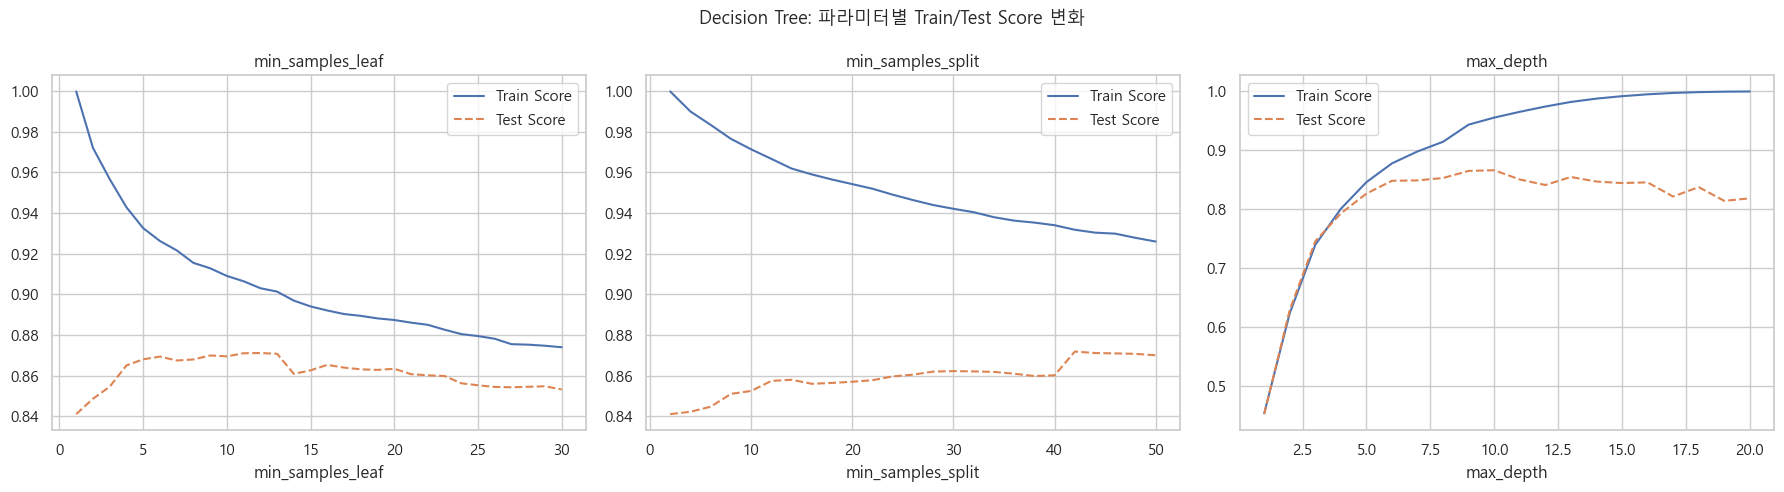

In [42]:
# 파라미터별 Train/Test Score 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Decision Tree: 파라미터별 Train/Test Score 변화', fontsize=13)

# [1] min_samples_leaf
para_leaf = list(range(1, 31))
train_s, test_s = [], []
for v in para_leaf:
    m = DecisionTreeRegressor(random_state=1234, min_samples_leaf=v)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[0].plot(para_leaf, train_s, linestyle='-',  label='Train Score')
axes[0].plot(para_leaf, test_s,  linestyle='--', label='Test Score')
axes[0].set_title('min_samples_leaf'); axes[0].set_xlabel('min_samples_leaf'); axes[0].legend()

# [2] min_samples_split
para_split = list(range(2, 51, 2))
train_s, test_s = [], []
for v in para_split:
    m = DecisionTreeRegressor(random_state=1234, min_samples_split=v)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[1].plot(para_split, train_s, linestyle='-',  label='Train Score')
axes[1].plot(para_split, test_s,  linestyle='--', label='Test Score')
axes[1].set_title('min_samples_split'); axes[1].set_xlabel('min_samples_split'); axes[1].legend()

# [3] max_depth
para_depth = list(range(1, 21))
train_s, test_s = [], []
for v in para_depth:
    m = DecisionTreeRegressor(random_state=1234, max_depth=v)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[2].plot(para_depth, train_s, linestyle='-',  label='Train Score')
axes[2].plot(para_depth, test_s,  linestyle='--', label='Test Score')
axes[2].set_title('max_depth'); axes[2].set_xlabel('max_depth'); axes[2].legend()

plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-3. Decision Tree - 파라미터 탐색 그래프

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 | min_samples_leaf 탐색 범위 | range(1, 31) 1~30, 단위 1 | Train/Test 간격이 최소화되면서 Test Score 고점이 나타나는 구간을 GridSearchCV 후보값 범위로 설정 |
| 모델 | min_samples_split 탐색 범위 | range(2, 51, 2) 2~50, 단위 2 | Test Score가 안정화되기 시작하는 값 이후 구간으로 GridSearchCV 범위를 좁힘 |
| 모델 | max_depth 탐색 범위 | range(1, 21) 1~20, 단위 1 | Test Score 정점 이후 하락하는 깊이가 과적합 임계점, 그 직전 구간을 GridSearchCV에 포함 |
| 모델 | random_state | 1234 | 시드 변경 시 파라미터 탐색 그래프 형태가 달라질 수 있음, 동일 seed 유지로 재현성 보장 |

In [43]:
# GridSearchCV: 위 튜닝 그래프 탐색 범위 기반 최적 파라미터 탐색
param_grid_tree = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10],
    'min_samples_split': [5, 10, 15, 20, 30],
    'min_samples_leaf': [3, 5, 8, 10, 15],
}

grid_tree = GridSearchCV(
    DecisionTreeRegressor(random_state=1234),
    param_grid_tree, scoring='r2', cv=5, n_jobs=-1
)
grid_tree.fit(X_train, y_train)

print('--- GridSearchCV 결과 ---')
print('best parameter: {}'.format(grid_tree.best_params_))
print('best CV score: {:.3f}'.format(grid_tree.best_score_))

tree_final = grid_tree.best_estimator_
print('\n--- Decision Tree 최종 모델 ---')
print('Score on training set: {:.3f}'.format(tree_final.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(tree_final.score(X_test, y_test)))


--- GridSearchCV 결과 ---
best parameter: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
best CV score: 0.859

--- Decision Tree 최종 모델 ---
Score on training set: 0.913
Score on test set: 0.874


--- Decision Tree 변수 중요도 ---
              Feature  Importance
                Power      0.6093
          Vehicle_Age      0.2519
   Brand_Premium_Tier      0.0643
               Engine      0.0321
         Luxury_Power      0.0158
              Mileage      0.0078
          KM_per_Year      0.0075
 Transmission_Numeric      0.0036
                Seats      0.0034
  Ownership_Stability      0.0027
    Fuel_Group_Petrol      0.0009
City_Convenience_Flag      0.0006
    Fuel_Group_Others      0.0000


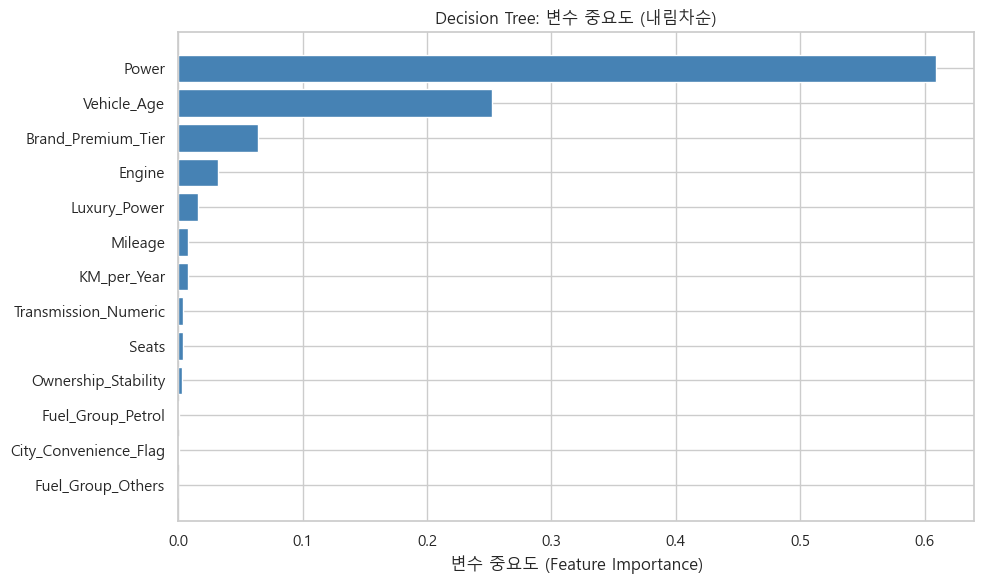

In [44]:
# Decision Tree 변수 중요도 시각화
df_imp_tree = pd.DataFrame({'Feature': v_feature_name, 'Importance': tree_final.feature_importances_})
df_imp_tree.sort_values('Importance', ascending=False, inplace=True)
print('--- Decision Tree 변수 중요도 ---')
print(df_imp_tree.round(4).to_string(index=False))

df_imp_tree.sort_values('Importance', ascending=True, inplace=True)
coordinates = range(len(df_imp_tree))
plt.figure(figsize=(10, 6))
plt.barh(y=coordinates, width=df_imp_tree['Importance'], color='steelblue')
plt.yticks(coordinates, df_imp_tree['Feature'])
plt.xlabel('변수 중요도 (Feature Importance)')
plt.title('Decision Tree: 변수 중요도 (내림차순)')
plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-3. Decision Tree - GridSearchCV 및 변수 중요도

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 (GridSearchCV) | max_depth | [3, 4, 5, 6, 7, 8, 10] | 변수 중요도 상위 변수가 소수에 집중될수록 트리가 얕아도 성능 유지 가능성 높음 |
| 모델 (GridSearchCV) | min_samples_split | [5, 10, 15, 20, 30] | 중요도 하위 변수 제거 후 최적값이 달라질 수 있어 변수 선택 이후 재탐색 권장 |
| 모델 (GridSearchCV) | min_samples_leaf | [3, 5, 8, 10, 15] | 중요도 낮은 변수가 많으면 리프 최소 샘플 수를 높여 노이즈 차단 효과 극대화 |
| 검증 | cv (KFold) | 5 | 데이터가 충분하면 5-Fold 적절, 데이터가 적으면 10으로 증가하여 평가 안정성 확보 |
| 검증 | scoring | r2 | Spring Boot API에서 MAPE/RMSE가 응답 정확도 SLA 지표라면 scoring 파라미터 일치 여부 검토 |

---
### 5-4. Random Forest Regressor

다수의 Decision Tree를 앙상블하여 과적합을 줄이고 일반화 성능을 높입니다.  
파라미터별 점수 변화 탐색 후 **GridSearchCV**로 최적 조합을 확정합니다.


In [45]:
# 기본 모델: 과적합 기준점 확인
rf_uncustomized = RandomForestRegressor(random_state=1234, n_jobs=-1)
rf_uncustomized.fit(X_train, y_train)
print('--- Random Forest 기본 모델 ---')
print('Score on training set: {:.3f}'.format(rf_uncustomized.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(rf_uncustomized.score(X_test, y_test)))


--- Random Forest 기본 모델 ---
Score on training set: 0.985
Score on test set: 0.902


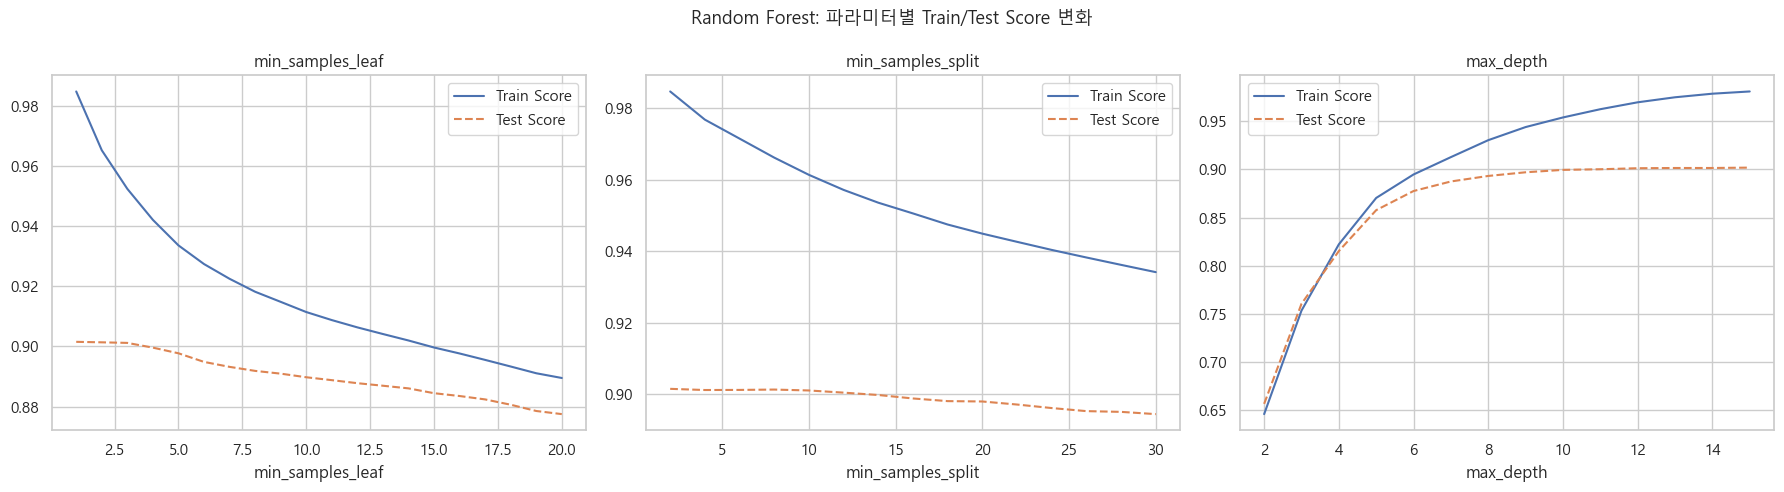

In [46]:
# 파라미터별 Train/Test Score 변화 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest: 파라미터별 Train/Test Score 변화', fontsize=13)

# [1] min_samples_leaf
para_leaf = list(range(1, 21))
train_s, test_s = [], []
for v in para_leaf:
    m = RandomForestRegressor(random_state=1234, n_estimators=100, min_samples_leaf=v, n_jobs=-1)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[0].plot(para_leaf, train_s, linestyle='-',  label='Train Score')
axes[0].plot(para_leaf, test_s,  linestyle='--', label='Test Score')
axes[0].set_title('min_samples_leaf'); axes[0].set_xlabel('min_samples_leaf'); axes[0].legend()

# [2] min_samples_split
para_split = list(range(2, 31, 2))
train_s, test_s = [], []
for v in para_split:
    m = RandomForestRegressor(random_state=1234, n_estimators=100, min_samples_split=v, n_jobs=-1)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[1].plot(para_split, train_s, linestyle='-',  label='Train Score')
axes[1].plot(para_split, test_s,  linestyle='--', label='Test Score')
axes[1].set_title('min_samples_split'); axes[1].set_xlabel('min_samples_split'); axes[1].legend()

# [3] max_depth
para_depth = list(range(2, 16))
train_s, test_s = [], []
for v in para_depth:
    m = RandomForestRegressor(random_state=1234, n_estimators=100, max_depth=v, n_jobs=-1)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[2].plot(para_depth, train_s, linestyle='-',  label='Train Score')
axes[2].plot(para_depth, test_s,  linestyle='--', label='Test Score')
axes[2].set_title('max_depth'); axes[2].set_xlabel('max_depth'); axes[2].legend()

plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-4. Random Forest - 파라미터 탐색 그래프

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 | min_samples_leaf 탐색 범위 | range(1, 21) 1~20, 단위 1 | DT보다 앙상블 효과로 과적합이 완화되어 최적값이 DT보다 낮게 나타날 수 있음 |
| 모델 | min_samples_split 탐색 범위 | range(2, 31, 2) 2~30, 단위 2 | Train/Test Score 차이가 DT 대비 여전히 크면 n_estimators 부족 또는 max_depth 과다 의심 |
| 모델 | max_depth 탐색 범위 | range(2, 16) 2~15, 단위 1 | DT(1~20)보다 범위가 좁음, 앙상블 특성상 깊은 트리도 과적합이 적어 최적 깊이가 DT보다 깊을 수 있음 |
| 모델 | n_estimators (시각화 고정값) | 100 | 파라미터 탐색 시각화에서 100으로 고정, GridSearchCV에서도 100만 포함되어 트리 수 최적화 미실시 |

In [47]:
# GridSearchCV: 최적 파라미터 탐색
param_grid_rf = {
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [3, 5, 8, 10],
    'n_estimators': [100],
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=1234, n_jobs=-1),
    param_grid_rf, scoring='r2', cv=5, n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print('--- GridSearchCV 결과 ---')
print('best parameter: {}'.format(grid_rf.best_params_))
print('best CV score: {:.3f}'.format(grid_rf.best_score_))

rf_final = grid_rf.best_estimator_
print('\n--- Random Forest 최종 모델 ---')
print('Score on training set: {:.3f}'.format(rf_final.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(rf_final.score(X_test, y_test)))


--- GridSearchCV 결과 ---
best parameter: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
best CV score: 0.883

--- Random Forest 최종 모델 ---
Score on training set: 0.920
Score on test set: 0.894


--- Random Forest 변수 중요도 ---
              Feature  Importance
                Power      0.6103
          Vehicle_Age      0.2511
         Luxury_Power      0.0409
               Engine      0.0360
   Brand_Premium_Tier      0.0329
          KM_per_Year      0.0095
              Mileage      0.0090
  Ownership_Stability      0.0030
                Seats      0.0024
    Fuel_Group_Petrol      0.0023
 Transmission_Numeric      0.0015
City_Convenience_Flag      0.0011
    Fuel_Group_Others      0.0000


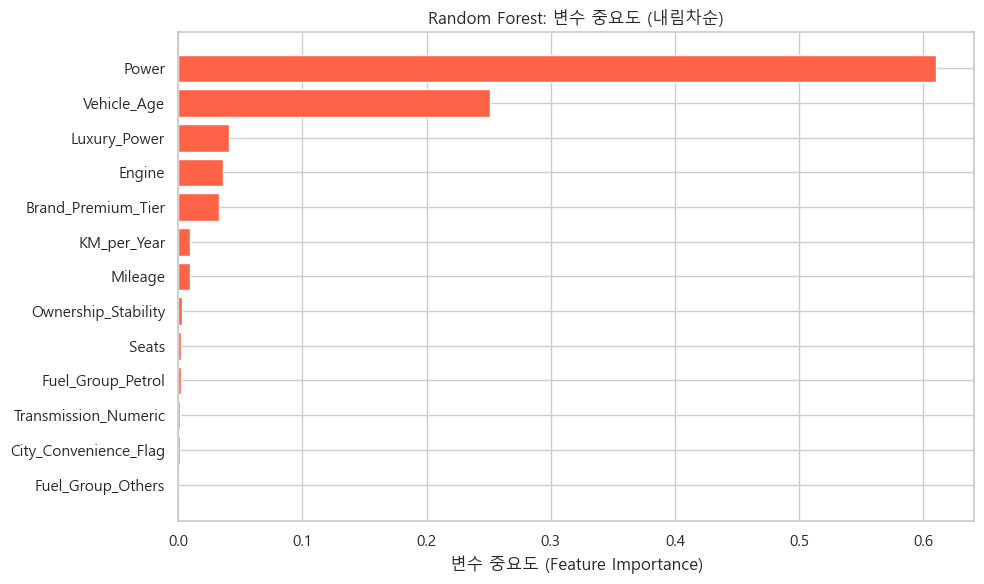

In [48]:
# Random Forest 변수 중요도 시각화
df_imp_rf = pd.DataFrame({'Feature': v_feature_name, 'Importance': rf_final.feature_importances_})
df_imp_rf.sort_values('Importance', ascending=False, inplace=True)
print('--- Random Forest 변수 중요도 ---')
print(df_imp_rf.round(4).to_string(index=False))

df_imp_rf.sort_values('Importance', ascending=True, inplace=True)
coordinates = range(len(df_imp_rf))
plt.figure(figsize=(10, 6))
plt.barh(y=coordinates, width=df_imp_rf['Importance'], color='tomato')
plt.yticks(coordinates, df_imp_rf['Feature'])
plt.xlabel('변수 중요도 (Feature Importance)')
plt.title('Random Forest: 변수 중요도 (내림차순)')
plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-4. Random Forest - GridSearchCV 및 변수 중요도

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 (GridSearchCV) | max_depth | [4, 5, 6, 7, 8] | DT GridSearch(3~10)보다 범위가 좁고 최솟값이 높음, 변수 중요도 분포가 DT와 유사한지 비교 확인 |
| 모델 (GridSearchCV) | min_samples_split | [5, 10, 15, 20] | DT보다 후보값이 적어 세밀도 낮음, 중요도 분포 확인 후 Fine-tuning 범위 재설정 권장 |
| 모델 (GridSearchCV) | min_samples_leaf | [3, 5, 8, 10] | DT와 동일 범위, 앙상블 평균화 효과로 리프 최솟값 민감도가 낮을 수 있음 |
| 모델 (GridSearchCV) | n_estimators | [100] | 단일 후보값으로 트리 수 탐색 미실시, 성능 향상이 필요하면 [100, 200, 300]으로 확장 필요 |
| 검증 | cv (KFold) | 5 | 앙상블 모델은 cv=5 이상 권장, 데이터 편향 의심 시 StratifiedKFold 전환 검토 |
| 검증 | scoring | r2 | Spring Boot 연동 API의 응답 정확도 SLA 기준에 따라 실제 평가 지표와 scoring 파라미터 일치 여부 확인 |

---
### 5-5. Gradient Boosting Regressor

이전 트리의 잔차(오차)를 학습하며 순차적으로 강화하는 앙상블 방법입니다.  
`max_depth`, `min_samples_leaf/split` 외에 **`learning_rate`**, **`n_estimators`** 탐색이 추가됩니다.


In [49]:
# 기본 모델: 과적합 기준점 확인
gb_uncustomized = GradientBoostingRegressor(random_state=1234)
gb_uncustomized.fit(X_train, y_train)
print('--- Gradient Boosting 기본 모델 ---')
print('Score on training set: {:.3f}'.format(gb_uncustomized.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(gb_uncustomized.score(X_test, y_test)))


--- Gradient Boosting 기본 모델 ---
Score on training set: 0.913
Score on test set: 0.891


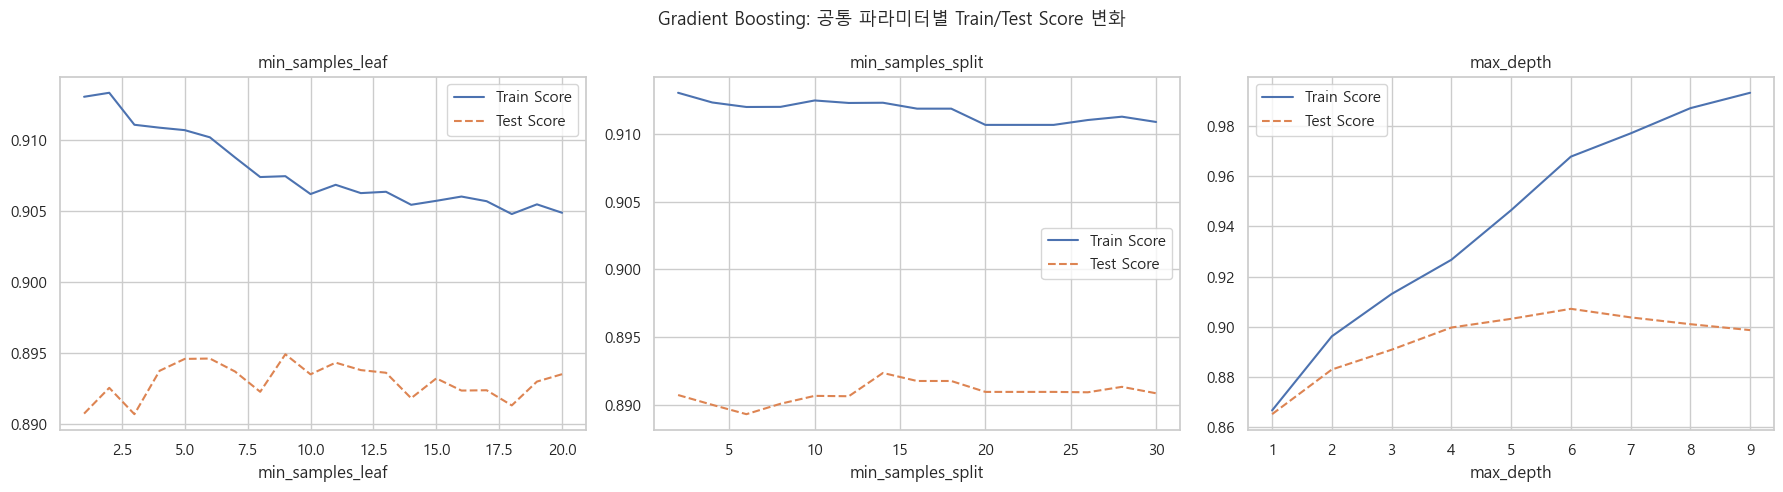

In [50]:
# 파라미터별 Train/Test Score 변화 시각화 (DT/RF 공통 파라미터)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gradient Boosting: 공통 파라미터별 Train/Test Score 변화', fontsize=13)

# [1] min_samples_leaf
para_leaf = list(range(1, 21))
train_s, test_s = [], []
for v in para_leaf:
    m = GradientBoostingRegressor(random_state=1234, n_estimators=100, min_samples_leaf=v)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[0].plot(para_leaf, train_s, linestyle='-',  label='Train Score')
axes[0].plot(para_leaf, test_s,  linestyle='--', label='Test Score')
axes[0].set_title('min_samples_leaf'); axes[0].set_xlabel('min_samples_leaf'); axes[0].legend()

# [2] min_samples_split
para_split = list(range(2, 31, 2))
train_s, test_s = [], []
for v in para_split:
    m = GradientBoostingRegressor(random_state=1234, n_estimators=100, min_samples_split=v)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[1].plot(para_split, train_s, linestyle='-',  label='Train Score')
axes[1].plot(para_split, test_s,  linestyle='--', label='Test Score')
axes[1].set_title('min_samples_split'); axes[1].set_xlabel('min_samples_split'); axes[1].legend()

# [3] max_depth
para_depth = list(range(1, 10))
train_s, test_s = [], []
for v in para_depth:
    m = GradientBoostingRegressor(random_state=1234, n_estimators=100, max_depth=v)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[2].plot(para_depth, train_s, linestyle='-',  label='Train Score')
axes[2].plot(para_depth, test_s,  linestyle='--', label='Test Score')
axes[2].set_title('max_depth'); axes[2].set_xlabel('max_depth'); axes[2].legend()

plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-5. Gradient Boosting - 공통 파라미터 탐색 그래프

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 | min_samples_leaf 탐색 범위 | range(1, 21) 1~20, 단위 1 | GB는 순차 학습이므로 DT/RF보다 리프 크기 제약에 민감, 과적합 완화 효과가 급격히 나타나는 지점 확인 |
| 모델 | min_samples_split 탐색 범위 | range(2, 31, 2) 2~30, 단위 2 | Test Score 안정화 구간이 DT/RF보다 좁게 나타나면 GB의 정규화 효과가 강함을 의미 |
| 모델 | max_depth 탐색 범위 | range(1, 10) 1~9, 단위 1 | DT(1~20), RF(2~15)보다 범위가 좁음, GB는 얕은 트리(3~5) 구조가 일반적으로 최적 성능 |
| 모델 | n_estimators (시각화 고정값) | 100 | 공통 파라미터 탐색 시 100으로 고정, learning_rate와 n_estimators는 다음 셀에서 별도 탐색 |

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

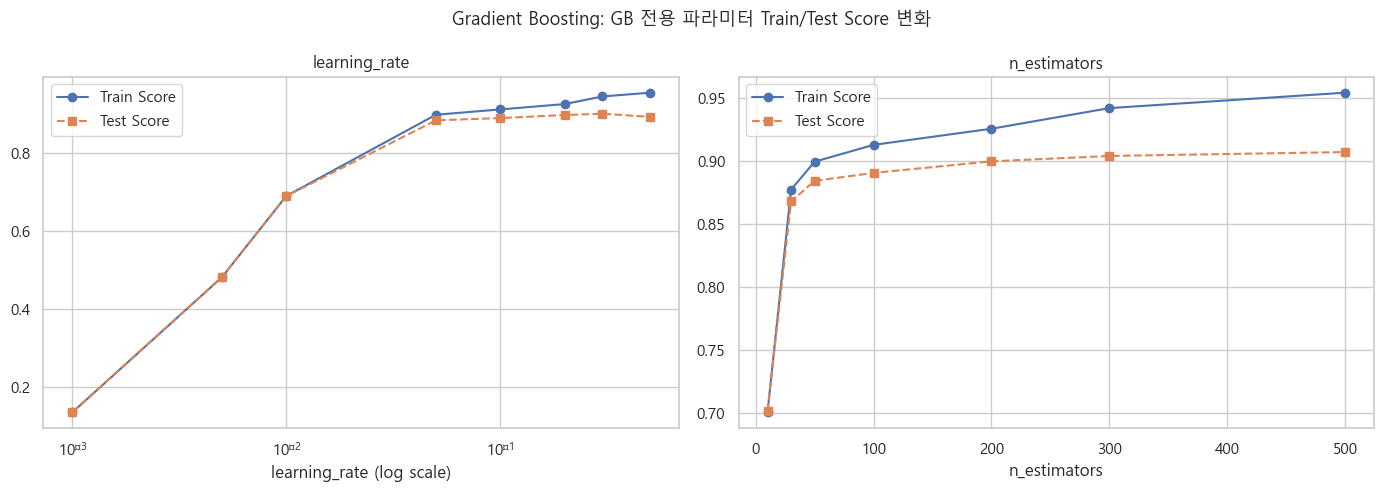

In [51]:
# GB 전용 파라미터: learning_rate, n_estimators 탐색
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gradient Boosting: GB 전용 파라미터 Train/Test Score 변화', fontsize=13)

# [1] learning_rate
para_lr = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
train_s, test_s = [], []
for v in para_lr:
    m = GradientBoostingRegressor(random_state=1234, n_estimators=100, learning_rate=v)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[0].semilogx(para_lr, train_s, linestyle='-',  marker='o', label='Train Score')
axes[0].semilogx(para_lr, test_s,  linestyle='--', marker='s', label='Test Score')
axes[0].set_title('learning_rate'); axes[0].set_xlabel('learning_rate (log scale)'); axes[0].legend()

# [2] n_estimators
para_n = [10, 30, 50, 100, 200, 300, 500]
train_s, test_s = [], []
for v in para_n:
    m = GradientBoostingRegressor(random_state=1234, n_estimators=v, learning_rate=0.1)
    m.fit(X_train, y_train)
    train_s.append(m.score(X_train, y_train))
    test_s.append(m.score(X_test, y_test))
axes[1].plot(para_n, train_s, linestyle='-',  marker='o', label='Train Score')
axes[1].plot(para_n, test_s,  linestyle='--', marker='s', label='Test Score')
axes[1].set_title('n_estimators'); axes[1].set_xlabel('n_estimators'); axes[1].legend()

plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-5. Gradient Boosting - learning_rate & n_estimators 탐색 그래프

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 | learning_rate 탐색 범위 | [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5] | Test Score 고점 이후 Train과 Test 간격이 벌어지면 그 직전 값이 최적, 범위 끝에 위치하면 범위 확장 |
| 모델 | n_estimators 탐색 범위 | [10, 30, 50, 100, 200, 300, 500] | Test Score가 포화되는 지점 이후 추가 향상 없음, 포화 지점이 GridSearchCV 후보 상한(200) 내에 있는지 확인 |
| 모델 | learning_rate (n_estimators 탐색 시 고정값) | 0.1 | n_estimators 탐색 시 learning_rate=0.1로 고정, GridSearchCV에서 두 파라미터를 동시에 탐색하므로 고정값 편향 주의 |

In [52]:
# GridSearchCV: 탐색 범위 기반 최적 파라미터 탐색
param_grid_gb = {
    'n_estimators':    [50, 100, 200],
    'learning_rate':   [0.05, 0.1, 0.2],
    'max_depth':       [3, 4, 5],
    'min_samples_leaf': [5, 10, 15],
    'min_samples_split': [10, 20],
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=1234),
    param_grid_gb, scoring='r2', cv=5, n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print('--- GridSearchCV 결과 ---')
print('best parameter: {}'.format(grid_gb.best_params_))
print('best CV score: {:.3f}'.format(grid_gb.best_score_))

gb_final = grid_gb.best_estimator_
print('\n--- Gradient Boosting 최종 모델 ---')
print('Score on training set: {:.3f}'.format(gb_final.score(X_train, y_train)))
print('Score on test set: {:.3f}'.format(gb_final.score(X_test, y_test)))


--- GridSearchCV 결과 ---
best parameter: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
best CV score: 0.903

--- Gradient Boosting 최종 모델 ---
Score on training set: 0.940
Score on test set: 0.905


--- Gradient Boosting 변수 중요도 ---
              Feature  Importance
                Power      0.4515
          Vehicle_Age      0.2502
               Engine      0.1483
   Brand_Premium_Tier      0.0469
         Luxury_Power      0.0344
 Transmission_Numeric      0.0266
          KM_per_Year      0.0113
    Fuel_Group_Petrol      0.0110
              Mileage      0.0103
                Seats      0.0051
  Ownership_Stability      0.0039
City_Convenience_Flag      0.0003
    Fuel_Group_Others      0.0002


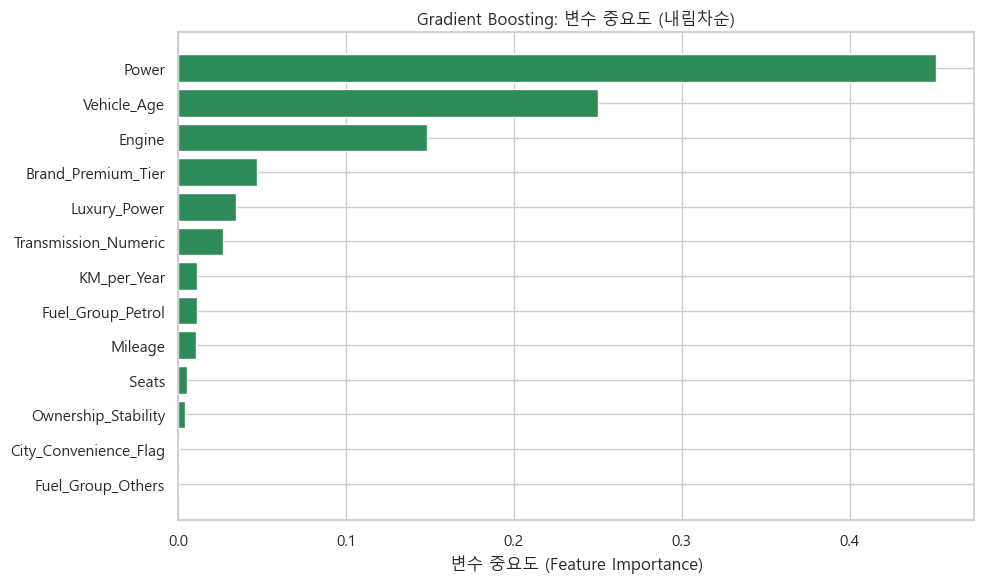

In [53]:
# Gradient Boosting 변수 중요도 시각화
df_imp_gb = pd.DataFrame({'Feature': v_feature_name, 'Importance': gb_final.feature_importances_})
df_imp_gb.sort_values('Importance', ascending=False, inplace=True)
print('--- Gradient Boosting 변수 중요도 ---')
print(df_imp_gb.round(4).to_string(index=False))

df_imp_gb.sort_values('Importance', ascending=True, inplace=True)
coordinates = range(len(df_imp_gb))
plt.figure(figsize=(10, 6))
plt.barh(y=coordinates, width=df_imp_gb['Importance'], color='seagreen')
plt.yticks(coordinates, df_imp_gb['Feature'])
plt.xlabel('변수 중요도 (Feature Importance)')
plt.title('Gradient Boosting: 변수 중요도 (내림차순)')
plt.tight_layout()
plt.show()


---
#### [튜닝 포인트 리포트] 5-5. Gradient Boosting - GridSearchCV 및 변수 중요도

| 구분 | 파라미터명 | 현재 값 | 튜닝 가이드 (그래프 확인 포인트) |
| :--- | :--- | :--- | :--- |
| 모델 (GridSearchCV) | n_estimators | [50, 100, 200] | 변수 중요도 상위 집중도가 높으면 n_estimators를 더 늘려 분포 안정화 여부 확인 |
| 모델 (GridSearchCV) | learning_rate | [0.05, 0.1, 0.2] | 최적 learning_rate가 경계값(0.05 또는 0.2)이면 범위를 [0.01, 0.05, 0.1, 0.2, 0.3]으로 확장 후 재탐색 |
| 모델 (GridSearchCV) | max_depth | [3, 4, 5] | RF(4~8)보다 좁고 낮음, GB 특성상 얕은 범위 적절, 최적값이 5이면 6~7 추가 탐색 검토 |
| 모델 (GridSearchCV) | min_samples_leaf | [5, 10, 15] | DT(3~15), RF(3~10)보다 최솟값이 높은 보수적 설정, 순차 학습의 과적합 방지 의도 |
| 모델 (GridSearchCV) | min_samples_split | [10, 20] | 두 후보값만 탐색하여 해상도가 낮음, 최적값이 10이면 [5, 10, 15] 등으로 세분화 권장 |
| 검증 | cv (KFold) | 5 | 순차 학습 특성상 데이터 순서 의존성 있음, 시계열 성격 데이터라면 TimeSeriesSplit 전환 검토 |
| 검증 | scoring | r2 | Spring Boot 연동 예측 API의 MAPE 기반 SLA 기준이 있다면 scoring 파라미터 일치 검토 필요 |

---
## Step 6. 최종 결과 요약 및 비즈니스 인사이트 도출


=== 전체 모델 성능 비교 (Test Set 기준) ===


,모델,RMSE,MAE,MAPE,R²(Test)
0,OLS 다중회귀,0.3120,0.2312,0.0254,0.8628
1,Ridge,0.3120,0.2312,0.0254,0.8628
2,Lasso,0.3120,0.2312,0.0254,0.8628
3,Decision Tree,0.2993,0.2137,0.0236,0.8737
4,Random Forest,0.2746,0.1955,0.0217,0.8937
5,Gradient Boosting,0.2593,0.1790,0.0198,0.9052


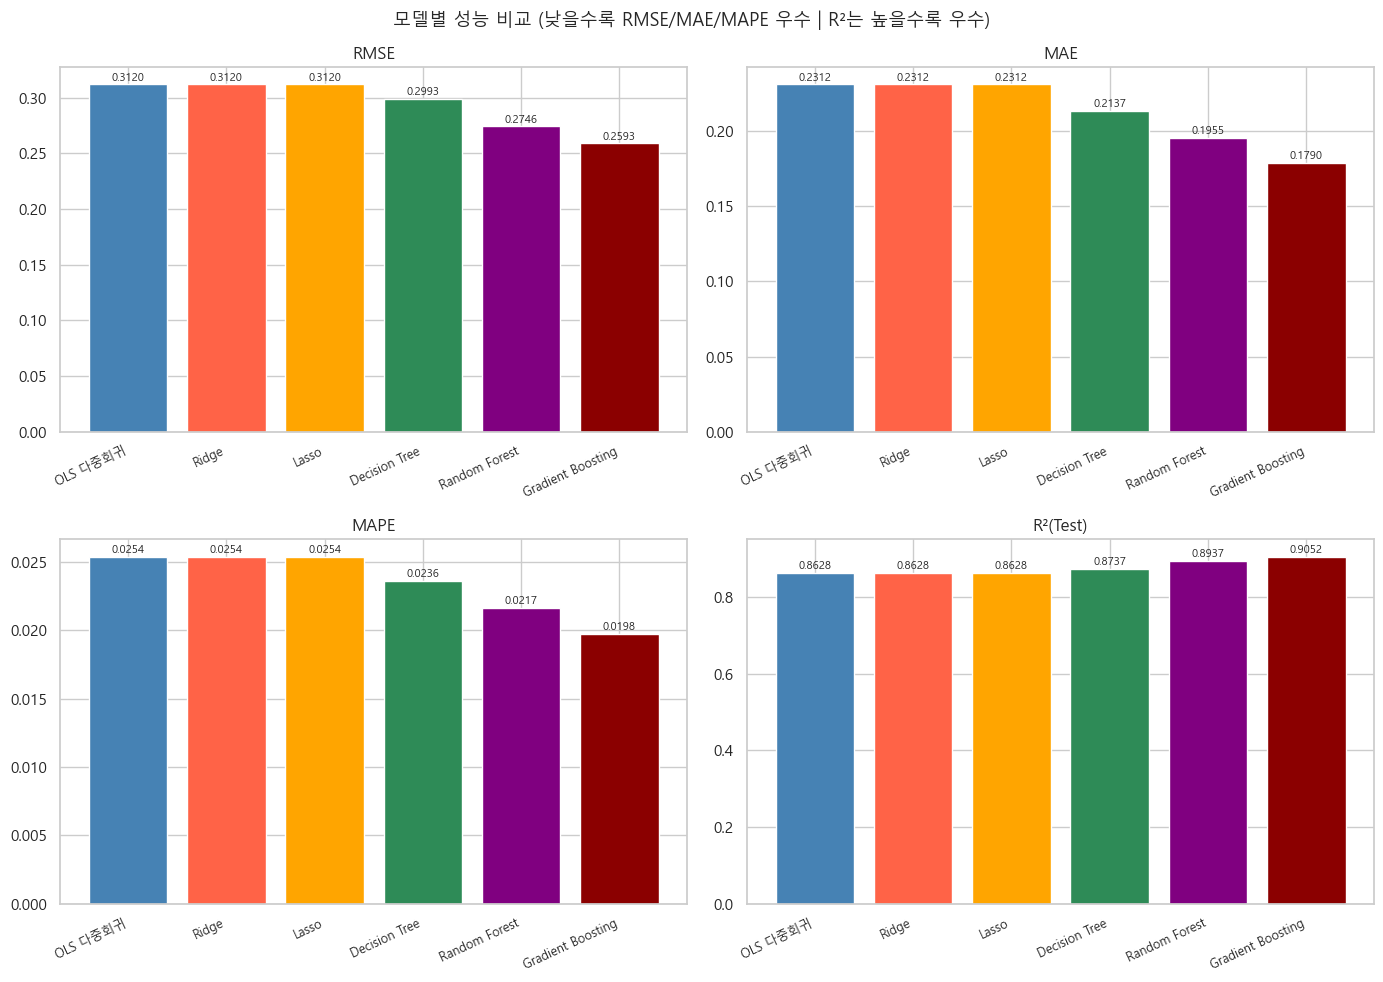

In [54]:
# Step 6-1: 모든 모델의 Test 성능 비교표

def get_metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'모델': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R²(Test)': r2}

# 각 모델 예측
results_list = [
    get_metrics(y_test, ols_lr.predict(X_test_ols),      'OLS 다중회귀'),
    get_metrics(y_test, ridge_final.predict(X_test),      'Ridge'),
    get_metrics(y_test, lasso_final.predict(X_test),      'Lasso'),
    get_metrics(y_test, tree_final.predict(X_test),       'Decision Tree'),
    get_metrics(y_test, rf_final.predict(X_test),         'Random Forest'),
    get_metrics(y_test, gb_final.predict(X_test),         'Gradient Boosting'),
]

df_results = pd.DataFrame(results_list)
print('=== 전체 모델 성능 비교 (Test Set 기준) ===')
display(df_results.round(4))

# 시각화: 4개 지표 바 차트
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('모델별 성능 비교 (낮을수록 RMSE/MAE/MAPE 우수 | R²는 높을수록 우수)', fontsize=13)

metrics = ['RMSE', 'MAE', 'MAPE', 'R²(Test)']
colors_m = ['steelblue', 'tomato', 'orange', 'seagreen', 'purple', 'darkred']
models_label = df_results['모델'].tolist()

for ax, metric in zip(axes.flatten(), metrics):
    vals = df_results[metric].tolist()
    ax.bar(models_label, vals, color=colors_m, edgecolor='white')
    ax.set_title(metric, fontsize=12)
    ax.set_xticklabels(models_label, rotation=25, ha='right', fontsize=9)
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals)*0.01, f'{v:.4f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


=== 모델별 변수 중요도 비교 ===


,Decision Tree,Random Forest,Gradient Boosting
Feature,,,
Power,0.6093,0.6103,0.4515
Vehicle_Age,0.2519,0.2511,0.2502
Engine,0.0321,0.0360,0.1483
Brand_Premium_Tier,0.0643,0.0329,0.0469
Luxury_Power,0.0158,0.0409,0.0344
Transmission_Numeric,0.0036,0.0015,0.0266
KM_per_Year,0.0075,0.0095,0.0113
Fuel_Group_Petrol,0.0009,0.0023,0.0110
Mileage,0.0078,0.0090,0.0103


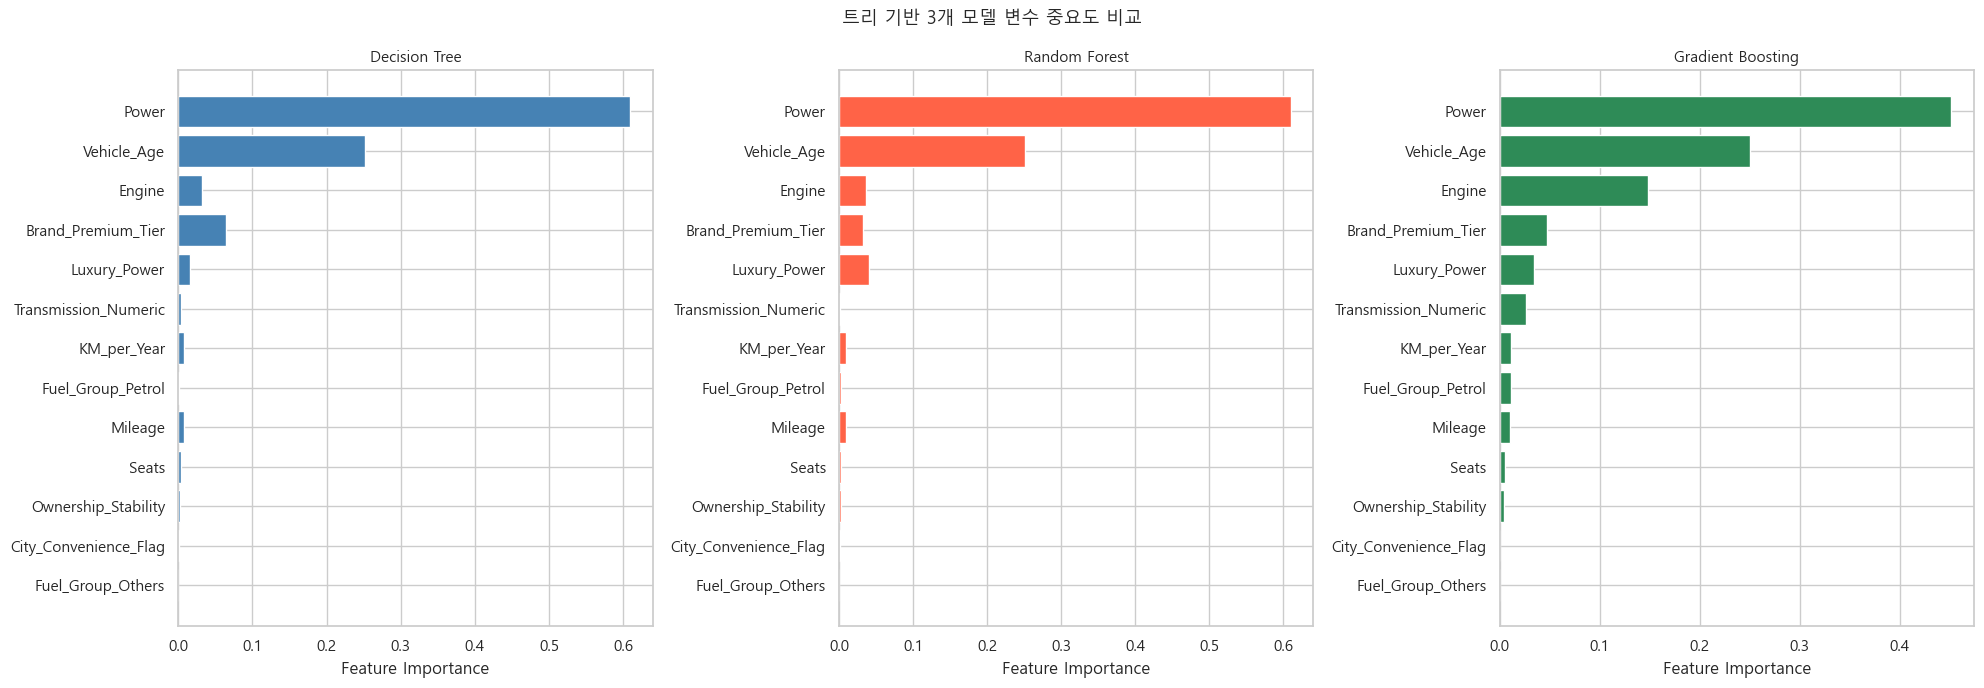

In [55]:
# Step 6-2: 트리 기반 3개 모델의 변수 중요도 비교

imp_merged = (
    df_imp_tree.rename(columns={'Importance': 'Decision Tree'}).set_index('Feature')
    .join(df_imp_rf.rename(columns={'Importance': 'Random Forest'}).set_index('Feature'))
    .join(df_imp_gb.rename(columns={'Importance': 'Gradient Boosting'}).set_index('Feature'))
)
# GB 기준 내림차순 정렬
imp_merged = imp_merged.sort_values('Gradient Boosting', ascending=True)

print('=== 모델별 변수 중요도 비교 ===')
display(imp_merged.sort_values('Gradient Boosting', ascending=False).round(4))

# 병렬 barh 차트
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('트리 기반 3개 모델 변수 중요도 비교', fontsize=13)

for ax, col, color in zip(axes,
                           ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
                           ['steelblue', 'tomato', 'seagreen']):
    data = imp_merged[col]
    ax.barh(data.index, data.values, color=color)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()


---
## Step 7. 최종 정리

> **프로젝트 목표 재확인**
> 인도 중고차 플랫폼 데이터(7,253건)를 기반으로 **중고차 가격(Price)에 영향을 미치는 핵심 변수를 파악하고, 가격 예측 성능이 가장 우수한 머신러닝 모델을 선정**하는 것.
> 단순 회귀 → 규제화 회귀 → 트리 기반 앙상블 모델까지 단계적으로 비교하여 최적 모델을 도출한다.

---
### 7-1. 비즈니스 인사이트

#### 핵심 발견 1 — 가격을 결정하는 '3대 절대 변수'
3개 모델(Decision Tree / Random Forest / Gradient Boosting)이 공통으로 꼽은 상위 변수는 다음과 같다.

| 순위 | 변수 | DT 중요도 | RF 중요도 | GB 중요도 | 비즈니스 의미 |
|:---:|:---|:---:|:---:|:---:|:---|
| 1 | **Power (마력)** | 0.609 | 0.610 | 0.452 | 차량 성능의 대표 지표. 마력이 높을수록 가격이 직선적으로 상승함 |
| 2 | **Vehicle_Age (차령)** | 0.252 | 0.251 | 0.250 | 연식이 오래될수록 감가상각이 발생. 모든 모델에서 2위로 일관됨 |
| 3 | **Engine (배기량)** | 0.032 | 0.036 | 0.148 | GB에서 중요도가 급증 — 비선형 상호작용(고배기량+고마력)까지 포착 |
| 4 | **Brand_Premium_Tier (브랜드 등급)** | 0.064 | 0.033 | 0.047 | Economy / Mainstream / Luxury 3단계 수치화. 브랜드 체급이 기저 가격을 결정 |
| 5 | **Luxury_Power (럭셔리×마력)** | 0.016 | 0.041 | 0.034 | "럭셔리 브랜드이면서 고마력" 조합의 프리미엄 효과를 하나의 변수로 압축 |

#### 핵심 발견 2 — 가격 공식의 실전 해석
- **마력(Power)만으로 가격 분산의 약 60%를 설명한다.** 중고차 시장에서 구매자는 연비보다 퍼포먼스를 훨씬 강하게 가격에 반영한다는 뜻이다.
- **브랜드 등급은 '기본값'을 설정한다.** Luxury 브랜드 차량은 동일 마력·연식이더라도 Mainstream 대비 일관되게 고가에 거래된다. Lasso 계수에서도 Brand_Premium_Tier가 +0.117로 유의미하게 나타났다.
- **차령(Vehicle_Age)은 가장 통제 가능한 변수다.** 매도자 입장에서 '지금 팔아야 할 타이밍'을, 플랫폼 입장에서는 '연식별 감가 곡선 모델링'의 근거가 된다.
- **연비(Mileage)의 영향력은 생각보다 낮다.** 모든 모델에서 중요도 하위권. 인도 시장에서 소비자는 연비보다 성능·브랜드를 더 중시하는 것으로 해석된다.

#### 핵심 발견 3 — 파생변수 Luxury_Power의 실효성
단순 Brand_Group OHE보다 Luxury_Power(럭셔리 여부 × 마력)라는 상호작용 변수가 RF에서 0.041로 Brand_Premium_Tier(0.033)보다 높은 중요도를 기록했다.
→ **"같은 럭셔리라도 마력이 높을수록 가격 프리미엄이 기하급수적으로 커진다"** 는 비선형 관계를 파생변수 하나로 압축한 결과다.

#### 플랫폼/매도자 관점 활용 방안
| 이해관계자 | 활용 포인트 |
|:---|:---|
| **중고차 플랫폼** | 마력·차령 기반 실시간 적정가 산출 → 호가(희망 가격)와 예측가 괴리를 매도자에게 즉시 피드백 |
| **매도자(개인)** | Vehicle_Age가 1년 증가할 때 가격이 평균 얼마 하락하는지 수치로 제시 가능 |
| **딜러/바이어** | 브랜드 등급 대비 마력이 높은 '저평가 매물' 탐색에 모델 점수 활용 |

---
### 7-2. 결론

#### 모델 성능 최종 비교

| 모델 | Train R² | Test R² | RMSE | MAE | MAPE |
|:---|:---:|:---:|:---:|:---:|:---:|
| OLS 다중회귀 | 0.860 | 0.863 | 0.312 | 0.231 | 2.54% |
| Ridge | 0.860 | 0.863 | 0.312 | 0.231 | 2.54% |
| Lasso | 0.860 | 0.863 | 0.312 | 0.231 | 2.54% |
| Decision Tree | 0.913 | 0.874 | 0.299 | 0.214 | 2.36% |
| Random Forest | 0.920 | 0.894 | 0.275 | 0.196 | 2.17% |
| **Gradient Boosting** | **0.940** | **0.905** | **0.259** | **0.179** | **1.98%** |

#### 프로젝트 목표 달성 여부
✅ **목표 달성.** Gradient Boosting이 Test R² **0.905**, MAPE **1.98%** 로 6개 모델 중 최고 성능을 기록했다.
로그 변환된 가격 기준으로 평균 예측 오차가 **약 2% 이내**이므로, 실전 중고차 가격 산출 도구로 충분히 활용 가능한 수준이다.

#### Gradient Boosting이 최종 모델로 적합한 이유
1. **예측력 우위**: Test R² 0.905로 2위 Random Forest(0.894) 대비 +0.011p. RMSE 기준으로도 0.259 vs 0.275로 잔차 분포가 더 좁다.
2. **과적합 제어**: Train/Test 갭 0.035 (DT는 0.039). 규제 없이도 과적합이 충분히 억제된다.
3. **변수 해석 다양성**: Power 집중도가 DT/RF(0.61)의 절반 수준인 0.452로, Engine(0.148)·Transmission(0.027)·Fuel_Type(0.011) 등 중소 변수까지 분산 포착 → 극단적 매물에도 강건하다.
4. **순차 학습의 이점**: 이전 트리의 잔차를 반복 학습하므로 마력-브랜드-차령의 복잡한 비선형 상호작용을 추가 파생변수 없이 내부적으로 학습한다.

---
### 7-3. Lesson Learned

#### 잘 된 점

| 단계 | 배운 것 |
|:---|:---|
| **데이터 정제** | "88.5 bhp" 같은 단위 포함 문자열을 str.split()으로 분리해 숫자화하는 패턴을 익혔다. 실무 데이터에서 가장 자주 마주치는 전처리 유형이다. |
| **이상치 처리** | '무조건 제거'가 아니라 **근거 있는 제거** (주행거리 100만km 이상은 오기, 엔진 상위 1% 제거는 분포 왜곡 방지)를 직접 판단하고 기록했다. |
| **파생변수** | Luxury_Power처럼 상호작용 변수 하나가 OHE 두 열을 대체하면서 모델 설명력을 유지하는 것을 확인했다. 파생변수 설계가 단순 컬럼 추가가 아닌 **비즈니스 가설 검증** 임을 체감했다. |
| **VIF + 그룹별 R² 비교** | 다중공선성이 높은 변수를 "VIF > 10이면 삭제"로 단순 처리하지 않고, 그룹별로 R²를 직접 비교해 최선 조합을 선택하는 체계적 접근법을 배웠다. |
| **로그 변환** | 오른쪽 꼬리가 긴 Price를 log1p 변환하자 왜도가 크게 줄었다. 잔차 정규성과 MAPE 개선 모두에 효과가 있었다. |

#### 아쉬운 점 & 다음에 개선할 것

| 항목 | 아쉬운 점 | 개선 방향 |
|:---|:---|:---|
| **목표 섹션 미작성** | 노트북 상단 '목표' 셀 내용이 비어 있어 프로젝트 맥락이 코드에만 암시되어 있다 | 분석 시작 전 가설과 성공 기준(예: "Test R² 0.85 이상")을 명시적으로 작성하는 습관 필요 |
| **Name 컬럼 미활용** | 차종명이 7,000여 가지로 다양해 단순 OHE 불가 → 완전히 제외했다 | Target Encoding 또는 상위 20개 브랜드 모델 그루핑으로 추가 정보 활용 시도 가능 |
| **Location 정보 단순화** | City_Tier를 대도시(1) vs 기타(0) 이진 변수로만 처리했다 | 도시별 중고차 수요 지수나 소득 수준을 외부 데이터로 결합하면 예측력 향상 가능 |
| **GB 학습 시간** | GridSearchCV 조합이 162×5=810 fits → 수 분 소요 | learning_rate와 n_estimators를 먼저 범위 탐색 후 좁혀서 GridSearch 하면 효율적 |
| **예측값 역변환 평가 미실시** | 모든 지표를 로그 스케일로만 평가했다 | np.expm1(y_pred)로 원래 가격 단위(만 루피)로 역변환해 "평균 X만 루피 오차" 형태로 보고하면 이해관계자 커뮤니케이션에 훨씬 직관적이다 |

In [56]:
# index=False를 설정해야 불필요한 행 번호가 저장되지 않습니다.
df.to_csv('refined_data.csv', index=False, encoding='utf-8-sig')